# Notebook to process lysosomal and mitochondrial morphology from cellprofiler features - this time from a merged cell CSV aready created
Inputs Required
 - Database with cellprofiler outputs
   - Mainly use the Per_Cell table for per-cell features
     - Intensity
     - AreaShape features
     - Ratio of organelle area to total cell area
     - Texture features
     - Granularity features
     - Radial intensity distribution about nucleus
   - May additionally want to use mitochdondria or lysosomes.csv if analyzing these specifically 
     - Note that lysosome segmentation is not perfect (but i'm proud of it)
 - Metadata CSV representing 96-well platemap
   - Long-form table containing passage number, staining conditons, treatments, etc
   - Produced automatically from an 8x12 table with the 96Well_PlateMap code
Outputs
- graphs for individual features
- clustering
## Set your paths here

In [1]:
# Imports
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# plotting
import plotly.express as px
import plotly.graph_objects as go

%matplotlib inline

import seaborn as sns

from mitolyso_plot_functions import *
from plate_information import *
from plate_preprocessing import *
from quality_control_functions import *
from single_csv_functions import (
    merge_ij_skeleton_features_into_combined_dataframe_from_folder,
)


## Import the big csv

In [93]:
# import from a giant csv
# csvpath = "/Volumes/AllieS/Morphology_data/"
csvpath = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/postprocessed_csvs"
filename = "total_combined_cell.csv"

# filename = "total_combined_cell_borders_excluded.csv"
combined_cell_df_mitolyso = pd.read_csv(os.path.join(csvpath, filename))
display(combined_cell_df_mitolyso.shape)

filename_borders_excluded = "total_combined_cell_borders_excluded.csv"

combined_cell_df_mitolyso = fix_column_names(combined_cell_df_mitolyso)

/tmp/ipykernel_2782/1203068257.py:7: DtypeWarning: Columns (1019,1020,1098,1099,1151,1152,1191,1192,3008) have mixed types. Specify dtype option on import or set low_memory=False.
  combined_cell_df_mitolyso = pd.read_csv(os.path.join(csvpath, filename))


(86868, 3015)

In [94]:
unique_combinations = combined_cell_df_mitolyso[
    ["Plate_Number", "PassageNumber"]
].drop_duplicates()

combos = list(unique_combinations.itertuples(index=False, name=None))
# display(sorted(combos))
display(combined_cell_df_mitolyso)

,Cell_Unique_ID,ImageNumber,Number_Object_Number,AreaShape_Area,AreaShape_BoundingBoxArea,AreaShape_BoundingBoxMaximum_X,AreaShape_BoundingBoxMaximum_Y,AreaShape_BoundingBoxMinimum_X,AreaShape_BoundingBoxMinimum_Y,AreaShape_Center_X,...,Lineage,AgeGroup,Drug,FlaggedBatch,LineageNumber,TimepointName,Plate_Number,Passage Group,AllGroups,Cell_Nuclei_Area_Ratio
0,0,1,1,164214.0,529720.0,1538.0,680.0,759.0,0.0,1214.520144,...,Doxo_LIN13-0C-b2-s3,9,Doxo,False,13,Doxo_P18 LIN13-0C-b2-s3 AG9,6.0,P16-18,Doxo,8.759014
1,1,1,2,104987.0,341880.0,1881.0,616.0,1326.0,0.0,1730.603799,...,Doxo_LIN13-0C-b2-s3,9,Doxo,False,13,Doxo_P18 LIN13-0C-b2-s3 AG9,6.0,P16-18,Doxo,7.714527
2,2,1,3,304312.0,667457.0,2086.0,1434.0,1407.0,451.0,1688.153264,...,Doxo_LIN13-0C-b2-s3,9,Doxo,False,13,Doxo_P18 LIN13-0C-b2-s3 AG9,6.0,P16-18,Doxo,8.460867
3,3,1,4,60598.0,134460.0,2160.0,973.0,1836.0,558.0,2017.926763,...,Doxo_LIN13-0C-b2-s3,9,Doxo,False,13,Doxo_P18 LIN13-0C-b2-s3 AG9,6.0,P16-18,Doxo,2.446328
4,4,8,1,26066.0,36036.0,1274.0,252.0,1131.0,0.0,1190.996355,...,Doxo_LIN13-0C-b2-s3,9,Doxo,False,13,Doxo_P18 LIN13-0C-b2-s3 AG9,6.0,P16-18,Doxo,2.012352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86863,86863,1199,6,38080.0,60225.0,300.0,1606.0,25.0,1387.0,182.323477,...,LIN5-0B-b3,0,NaN,False,5,P10 LIN5-0B-b3 AG0,1.0,P6-12,P6-12,2.468080
86864,86864,1199,7,67163.0,103972.0,1121.0,1910.0,843.0,1536.0,981.651862,...,LIN5-0B-b3,0,NaN,False,5,P10 LIN5-0B-b3 AG0,1.0,P6-12,P6-12,4.110594
86865,86865,1199,8,26348.0,51754.0,451.0,1762.0,222.0,1536.0,318.578070,...,LIN5-0B-b3,0,NaN,False,5,P10 LIN5-0B-b3 AG0,1.0,P6-12,P6-12,1.532039
86866,86866,1199,9,30452.0,35496.0,204.0,1782.0,0.0,1608.0,95.570439,...,LIN5-0B-b3,0,NaN,False,5,P10 LIN5-0B-b3 AG0,1.0,P6-12,P6-12,2.751355


In [95]:
intensity_cols = get_intensity_cols(combined_cell_df_mitolyso)
well_avg_cols = [f"{col}_WellAvg" for col in intensity_cols]
norm_intensity_cols = [f"{col}_WellNormalized" for col in intensity_cols]

combined_cell_df_mitolyso_test = normalize_intensity_to_well_average(
    combined_cell_df_mitolyso.copy(), intensity_cols
)
print("Intensity columns:", intensity_cols)
display(
    combined_cell_df_mitolyso_test[
        ["AllGroups", "Plate_Number", "Metadata_Well"]
        + intensity_cols
        + well_avg_cols
        + norm_intensity_cols
    ].head(20)
)

combined_cell_df_mitolyso = normalize_intensity_to_well_average(
    combined_cell_df_mitolyso, intensity_cols
)

Intensity columns: ['Nuclei_Intensity_MaxIntensity_DAPI_MAX', 'Nuclei_Intensity_MeanIntensity_DAPI_MAX', 'Nuclei_Intensity_MedianIntensity_DAPI_MAX', 'Nuclei_Intensity_MinIntensity_DAPI_MAX', 'Intensity_MaxIntensity_LAMP1_MAX', 'Intensity_MeanIntensity_LAMP1_MAX', 'Intensity_MedianIntensity_LAMP1_MAX', 'Intensity_MinIntensity_LAMP1_MAX', 'Intensity_MaxIntensity_MitoTracker_MAX', 'Intensity_MeanIntensity_MitoTracker_MAX', 'Intensity_MedianIntensity_MitoTracker_MAX', 'Intensity_MinIntensity_MitoTracker_MAX']


,AllGroups,Plate_Number,Metadata_Well,Nuclei_Intensity_MaxIntensity_DAPI_MAX,Nuclei_Intensity_MeanIntensity_DAPI_MAX,Nuclei_Intensity_MedianIntensity_DAPI_MAX,Nuclei_Intensity_MinIntensity_DAPI_MAX,Intensity_MaxIntensity_LAMP1_MAX,Intensity_MeanIntensity_LAMP1_MAX,Intensity_MedianIntensity_LAMP1_MAX,...,Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized,Nuclei_Intensity_MinIntensity_DAPI_MAX_WellNormalized,Intensity_MaxIntensity_LAMP1_MAX_WellNormalized,Intensity_MeanIntensity_LAMP1_MAX_WellNormalized,Intensity_MedianIntensity_LAMP1_MAX_WellNormalized,Intensity_MinIntensity_LAMP1_MAX_WellNormalized,Intensity_MaxIntensity_MitoTracker_MAX_WellNormalized,Intensity_MeanIntensity_MitoTracker_MAX_WellNormalized,Intensity_MedianIntensity_MitoTracker_MAX_WellNormalized,Intensity_MinIntensity_MitoTracker_MAX_WellNormalized
0,Doxo,6.0,A02,0.204486,0.041611,0.028519,0.006104,0.176089,0.022776,0.015106,...,0.751561,0.938404,1.417755,1.692728,1.876777,1.001091,1.128927,0.931614,0.945760,0.877750
1,Doxo,6.0,A02,0.207279,0.048724,0.031083,0.004456,0.200031,0.026528,0.015290,...,0.819117,0.685035,1.610516,1.971589,1.899526,1.063660,1.420950,1.028550,1.174185,0.731458
2,Doxo,6.0,A02,0.181369,0.033043,0.026886,0.003891,0.163668,0.018597,0.008377,...,0.708534,0.598232,1.317751,1.382187,1.040758,0.922881,1.043736,0.790153,0.729357,0.692447
3,Doxo,6.0,A02,0.209659,0.042705,0.028153,0.004318,0.173968,0.023050,0.011124,...,0.741910,0.663921,1.400678,1.713141,1.381990,1.055838,0.653228,0.995245,0.987838,0.726582
4,Doxo,6.0,A02,0.206683,0.050363,0.034379,0.004852,0.073548,0.009847,0.005951,...,0.905974,0.746031,0.592165,0.731857,0.739336,1.032375,0.768151,1.031483,1.112069,1.082558
5,Doxo,6.0,A02,0.219852,0.051424,0.033234,0.005203,0.091402,0.011788,0.007691,...,0.875815,0.799989,0.735906,0.876115,0.955450,1.040196,0.689106,1.205679,1.386580,1.204468
6,Doxo,6.0,A02,0.275319,0.055602,0.039765,0.004379,0.092943,0.016535,0.013077,...,1.047922,0.673305,0.748314,1.228937,1.624644,1.134049,0.897224,1.337964,1.560904,1.014289
7,Doxo,6.0,A02,0.256031,0.022049,0.010254,0.002502,0.122057,0.017161,0.011933,...,0.270224,0.384745,0.982723,1.275437,1.482464,0.946344,1.052026,1.039095,1.045946,1.141075
8,Doxo,6.0,A02,0.127047,0.030259,0.026856,0.004532,0.099580,0.008362,0.005234,...,0.707730,0.696765,0.801757,0.621485,0.650237,0.969807,1.398938,0.968296,0.951771,1.082558
9,Doxo,6.0,A02,0.170291,0.040006,0.029877,0.007874,0.090211,0.015371,0.010208,...,0.787349,1.210541,0.726323,1.142367,1.268246,0.969807,0.972124,1.142267,1.262349,0.863121


## Setup functions


### Remove problematic rows / columns from dataframe

In [162]:
def remove_problematic_rows_cols(df, plate_number, problematic_rows, problematic_cols, problematic_rows_cols_combo_only=None):
    """
    Remove rows and columns from the dataframe based on the specified plate number.

    Parameters:
    df (pd.DataFrame): The input dataframe.
    plate_number (int): The plate number to filter by.
    problematic_rows (list): List of problematic row numbers to remove.
    problematic_cols (list): List of problematic column numbers to remove.
    problematic_rows_cols_combo_only (list of tuples, optional): List of specific row-column combinations to remove. Each tuple should contain a row number and a column number.

    Returns:
    pd.DataFrame: The filtered dataframe with specified rows and columns removed.
    """
    this_df = df.copy().reset_index(names="Old_Index")  # Create a copy of the dataframe to avoid modifying the original
    # Filter by plate number
    filtered_df = this_df[this_df["Plate_Number"] == plate_number]
    
    problematic_indicies_df = pd.DataFrame()  # Initialize an empty dataframe to store problematic indices
    # if problematic_rows_cols_combo_only:
    # # filter the dataframe to find those combinations
    #     mask = pd.MultiIndex.from_frame(filtered_df[["Metadata_WellRow", "Metadata_WellColumn"]]).isin(problematic_rows_cols_combo_only)
    #     problematic_indicies_df = filtered_df.loc[mask]
    # # Remove problematic rows
    
    # if problematic_rows:
    #     if problematic_indicies_df.empty:
    #         problematic_indicies_df = filtered_df.loc[filtered_df["Metadata_WellRow"].astype(int).isin(problematic_rows)]
    #     else:
    #         problematic_indicies_df = problematic_indicies_df.loc[problematic_indicies_df["Metadata_WellRow"].astype(int).isin(problematic_rows)]

    # # Remove problematic columns
    # if problematic_cols:
    #     if problematic_indicies_df.empty:
    #         problematic_indicies_df = filtered_df.loc[filtered_df["Metadata_WellColumn"].astype(int).isin(problematic_cols)]
    #     else:
    #         problematic_indicies_df = problematic_indicies_df.loc[problematic_indicies_df["Metadata_WellColumn"].astype(int).isin(problematic_cols)]
    
    # # Remove the problematic rows and columns from the original dataframe and preserve the original structure
    if problematic_rows or problematic_cols or problematic_rows_cols_combo_only:
        row_mask = filtered_df["Metadata_WellRow"].astype(int).isin(problematic_rows) if problematic_rows else False
        col_mask = filtered_df["Metadata_WellColumn"].astype(int).isin(problematic_cols) if problematic_cols else False
        combo_mask = (
            pd.MultiIndex.from_frame(filtered_df[["Metadata_WellRow", "Metadata_WellColumn"]])
            .isin(problematic_rows_cols_combo_only)
            if problematic_rows_cols_combo_only
            else False
        )
        problematic_indicies_df = filtered_df.loc[row_mask | col_mask | combo_mask]
    if not problematic_indicies_df.empty:
        print(f"   rows from plate {plate_number} before: {filtered_df.shape}, after: {filtered_df[~filtered_df['Old_Index'].isin(problematic_indicies_df['Old_Index'])].shape}")
        this_df = this_df.loc[~this_df["Old_Index"].isin(problematic_indicies_df["Old_Index"])]
    else:
        print(f"No problematic rows or columns found for plate {plate_number}. No rows removed.")
    return this_df.drop(columns=["Old_Index"]).reset_index(drop=True)  # Drop the temporary index column before returning

plate_numbers_problematic_rows_cols = {
    1: {"problematic_rows": [2, 7], "problematic_cols": [4], "problematic_rows_cols_combo_only": None},
    2: {"problematic_rows": [], "problematic_cols": [], "problematic_rows_cols_combo_only": [(2,4),(3,4)]},
    3: {"problematic_rows": [2], "problematic_cols": [], "problematic_rows_cols_combo_only": [(3,4),(4,4)]},
    4: {"problematic_rows": [2], "problematic_cols": [], "problematic_rows_cols_combo_only": [(3,4),(4,4)]},
    5: {"problematic_rows": [], "problematic_cols": [], "problematic_rows_cols_combo_only": [(4,4),(5,4)]},
    6: {"problematic_rows": [], "problematic_cols": [], "problematic_rows_cols_combo_only": [(2,2),(3,2)]},
    7: {"problematic_rows": [], "problematic_cols": [], "problematic_rows_cols_combo_only": None},
}

filter_rows_df = combined_cell_df_mitolyso.copy()  # Start with the original dataframe
for plate_number in plate_numbers_problematic_rows_cols:
    problematic_rows = plate_numbers_problematic_rows_cols[plate_number]["problematic_rows"]
    problematic_cols = plate_numbers_problematic_rows_cols[plate_number]["problematic_cols"]
    problematic_rows_cols_combo_only = plate_numbers_problematic_rows_cols[plate_number]["problematic_rows_cols_combo_only"]
    if problematic_rows or problematic_cols or problematic_rows_cols_combo_only:
        print(f"Removing problematic rows and/or columns for plate {plate_number}:")
        if problematic_rows:
            print(f"  Problematic rows: {problematic_rows}")
        if problematic_cols:
            print(f"  Problematic columns: {problematic_cols}")
        if problematic_rows_cols_combo_only:
            print(f"  Problematic row-column combinations: {problematic_rows_cols_combo_only}")
        shape_before =filter_rows_df.shape
        filter_rows_df = remove_problematic_rows_cols(
            filter_rows_df, plate_number=plate_number, problematic_rows=problematic_rows, problematic_cols=problematic_cols, problematic_rows_cols_combo_only=problematic_rows_cols_combo_only
        )
        print(f"  Shape of full df before: {shape_before}, shape after: {filter_rows_df.shape}")
    else:
        print(f"No problematic rows or columns specified for plate {plate_number}. No rows removed.")

print(f"Original dataframe before: {combined_cell_df_mitolyso.shape}, shape after: {filter_rows_df.shape}")
filtered_rows_df = combined_cell_df_mitolyso.copy()  # Update the original dataframe with the filtered dataframe

Removing problematic rows and/or columns for plate 1:
  Problematic rows: [2, 7]
  Problematic columns: [4]
   rows from plate 1 before: (7005, 3042), after: (3247, 3042)
  Shape of full df before: (86868, 3041), shape after: (83110, 3041)
Removing problematic rows and/or columns for plate 2:
  Problematic row-column combinations: [(2, 4), (3, 4)]
   rows from plate 2 before: (9360, 3042), after: (8596, 3042)
  Shape of full df before: (83110, 3041), shape after: (82346, 3041)
Removing problematic rows and/or columns for plate 3:
  Problematic rows: [2]
  Problematic row-column combinations: [(3, 4), (4, 4)]
   rows from plate 3 before: (14337, 3042), after: (10793, 3042)
  Shape of full df before: (82346, 3041), shape after: (78802, 3041)
Removing problematic rows and/or columns for plate 4:
  Problematic rows: [2]
  Problematic row-column combinations: [(3, 4), (4, 4)]
   rows from plate 4 before: (12639, 3042), after: (9490, 3042)
  Shape of full df before: (78802, 3041), shape afte

### Filter out the poorly segmented cells based on the previously defined quality control filters and rename the columns

In [109]:
# filtered_combined_cell_df_mitolyso, filtered_combined_summary_df = (
#     get_filtered_df_and_export_summary_to_csv(
#             combined_cell_df_mitolyso,
#             group_col="Plate_Number",
#             groups=sorted(combined_cell_df_mitolyso["Plate_Number"].unique()),
#             savepath="filtering_summaries",
#             individual_filters=False,
#         )
# )
# filtered_combined_cell_df_mitolyso, filtered_combined_summary_df = (
#     get_filtered_df_and_export_summary_to_csv(
#         combined_cell_df_mitolyso,
#         group_col="AllGroups",
#         groups=get_all_group_order(),
#         savepath="filtering_summaries",
#         individual_filters=False
#     )
# )

In [163]:
final_filtered_df, final_filtered_summary_df = get_filtered_df_and_export_summary_to_csv(
    filtered_rows_df,
    reference_df=filtered_rows_df,
    savepath="filtering_summaries",
)

Manually overriding rows removed for Cell Size Filter Bottom Band to 1448
Manually overriding rows removed for Cell Size Filter Top Band to 68
Manually overriding rows removed for Nuclear Size Filter Bottom Band to 1022
Manually overriding rows removed for Nuclear Size Filter Top Band to 117
Max Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized threshold: 2.5
One or more max neighbor thresholds are 0. Trying with closest distance


## Search Column Names

In [111]:
# colnames
# sns.barplot(filter_df_2, x="AllGroups",y="AreaShape_Area", hue="Plate_Number", palette=colour_dict)
colnames = search_column_name(combined_cell_df_mitolyso, "Plate")
display(combined_cell_df_mitolyso[colnames])

Query: Plate
    Metadata_Plate
    Plate_Number


,Metadata_Plate,Plate_Number
0,20250410_rep06,6.0
1,20250410_rep06,6.0
2,20250410_rep06,6.0
3,20250410_rep06,6.0
4,20250410_rep06,6.0
...,...,...
86863,20240313_rep01,1.0
86864,20240313_rep01,1.0
86865,20240313_rep01,1.0
86866,20240313_rep01,1.0


In [ ]:
test_query_df = combined_cell_df_mitolyso.query(
    "Plate_Number == 6 and Metadata_WellColumn == 2"
)

# display(test_query_df[[
#     "Plate_Number",
#     "Metadata_RowColFieldCode",
#     "Number_Object_Number",
#     "AllGroups",
#     "AreaShape_Area",
#     "Children_Mitochondria_Count",
#     "Children_Lysosomes_Count",
#     "Intensity_MeanIntensity_LAMP1_MAX",
#     "Intensity_MeanIntensity_MitoTracker_MAX",
# ]].head(20))
# display(
#     combined_cell_df_mitolyso.groupby(["Plate_Number", "Metadata_WellRow"])[
#         "Intensity_MeanIntensity_LAMP1_MAX"
#     ].describe()
# )


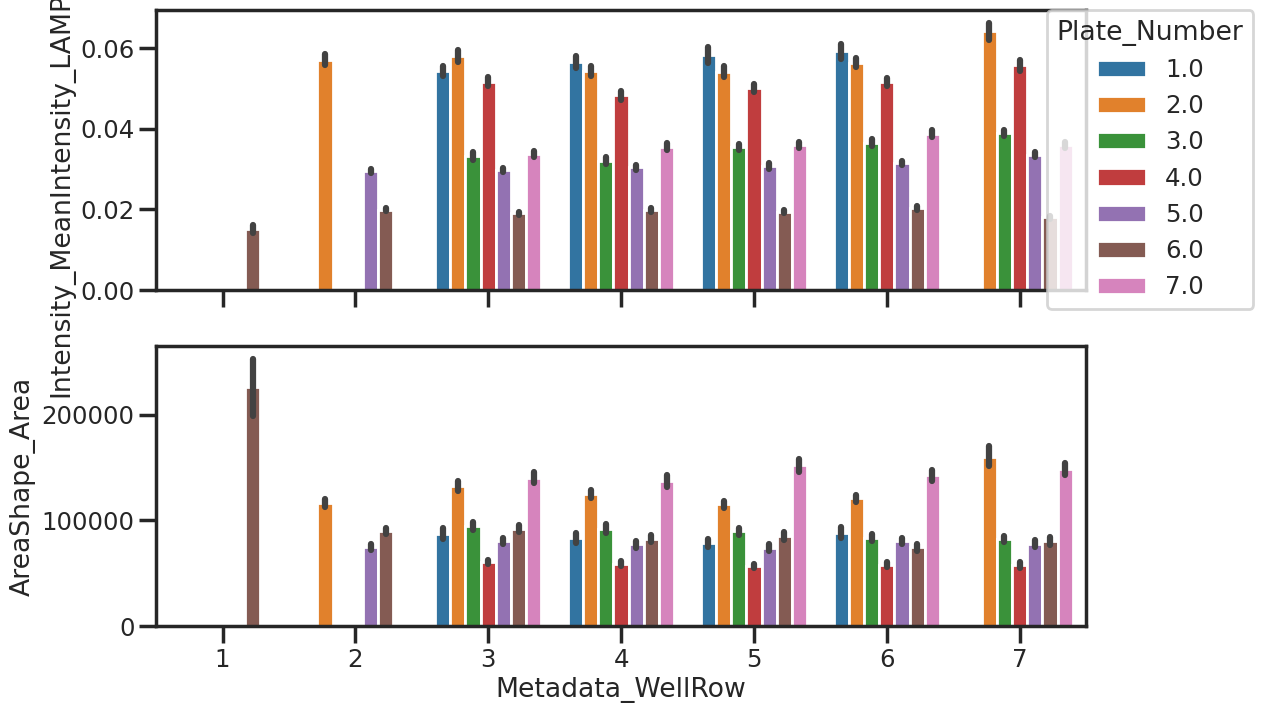

In [133]:
def compare_features_barplots(
    df,
    feature1,
    feature2,
    group_col="Plate_Number",
    hue_col="Metadata_WellColumn",
    figsize=(12, 8),
):
    fig, ax = plt.subplots(2, 1, figsize=figsize, sharex=True)
    sns.barplot(
        data=df,
        ax=ax[0],
        x=group_col,
        y=feature1,
        hue=hue_col,
        palette="tab10",
        legend=True,
    )
    sns.barplot(
        data=df,
        ax=ax[1],
        x=group_col,
        y=feature2,
        hue=hue_col,
        palette="tab10",
        legend=False,
    )
    ax[0].legend(
        loc="upper right", bbox_to_anchor=(1.18, 1), borderaxespad=0, title=hue_col
    )
    plt.show()


compare_features_barplots(
    final_filtered_df,
    "Intensity_MeanIntensity_LAMP1_MAX",
    "AreaShape_Area",
    hue_col="Plate_Number",
    group_col="Metadata_WellRow",
    figsize=(12, 8)
)
# fig,ax =plt.subplots(2, 1,figsize=(12, 6),sharex=True)
# sns.barplot(combined_cell_df_mitolyso, ax=ax[0], hue="Metadata_WellColumn", y="Children_Lysosomes_Count", x="Plate_Number", palette="tab10",legend=True)
# sns.barplot(combined_cell_df_mitolyso, ax=ax[1], hue="Metadata_WellColumn", y="Children_Mitochondria_Count", x="Plate_Number", palette="tab10",legend=False)
# ax[0].legend(loc="upper right", bbox_to_anchor=(1.1, 1), borderaxespad=0, title="Well Column")
# plt.show()


# Define the cell features


### Join in imageJ skeleton features
Side note; make sure to use TotalMitochondria_Object_Number for the skeleton analysis if I want to join the correct items

In [114]:
# Add ijskeleton columns
ij_csvpath = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/IJ_Output/"
final_filtered_df["Metadata_PlateNumber"] = final_filtered_df["Plate_Number"].astype(
    int
)

final_filtered_df_with_ijskeleton = (
    merge_ij_skeleton_features_into_combined_dataframe_from_folder(
        final_filtered_df,
        ij_csvpath,
        ij_keys=["Metadata_PlateNumber", "Metadata_RowColField", "ObjectNumber"],
        parent_keys=[
            "Metadata_PlateNumber",
            "Metadata_RowColFieldCode",
            "TotalMitochondria_Number_Object_Number",
        ],
        show=True,
        check_duplicates=True,
    )
)

def fix_ij_skeleton_column_names(df, colnames=None):
    df = df.copy()
    if colnames is None:
        colnames = search_column_name(df, "IJ_Mitochondria")
    new_colnames = {}   
    for col in colnames:
        #Make _Max_ more clear for largest structure
        if "_Max_" in col:
            new_colname = col.replace("_Max_", "_LargestStructure_")
        elif "_Total_" in col:
            new_colname = col.replace("_Total_", "_TotalAcrossAllStructures_")
        elif col.endswith("_Max"):
            new_colname = col.replace("_Max", "_MaxAcrossAllStructures")
        else:
            new_colname = col
        new_colnames[col] = new_colname
    df.rename(columns=new_colnames, inplace=True)
    return df

final_filtered_df_with_ijskeleton = fix_ij_skeleton_column_names(final_filtered_df_with_ijskeleton)

display(
    final_filtered_df_with_ijskeleton[
        final_filtered_df_with_ijskeleton["Metadata_PlateNumber"] == 4
    ][
        [
            "Metadata_PlateNumber",
            "Metadata_RowColFieldCode",
            "TotalMitochondria_Number_Object_Number",
            "TotalMitochondria_AreaShape_Area",
            "IJ_Mitochondria_Masks_MitochondrialFootprint"
        ]
        + search_column_name(final_filtered_df_with_ijskeleton, "IJ_Mitochondria")
    ].head(20)
)

Processing rep3_mito_masks.csv in folder rep3_mito_masks...
Processing rep5_mito_masks.csv in folder rep5_mito_masks...
Skipping test, not a CSV file.
Processing rep2_mito_masks.csv in folder rep2_mito_masks...
Processing rep7_mito_masks.csv in folder rep7_mito_masks...
Processing rep4_mito_masks.csv in folder rep4_mito_masks...
Processing rep6_mito_masks.csv in folder rep6_mito_masks...
Processing rep1_mito_masks.csv in folder rep1_mito_masks...
IJ_Mitochondria_Masks merge keys: 0 duplicate rows found for keys ['ImageTitle', 'Metadata_PlateNumber', 'Metadata_RowColField', 'ObjectNumber']
shape before merge: (68263, 3042)
shape after merge: (68263, 3083)
Query: IJ_Mitochondria
    IJ_Mitochondria_Masks_Metadata_ThresholdingOP
    IJ_Mitochondria_Masks_MitochondrialFootprint
    IJ_Mitochondria_Masks_BranchLength_Mean
    IJ_Mitochondria_Masks_BranchLength_Median
    IJ_Mitochondria_Masks_BranchLength_Stdev
    IJ_Mitochondria_Masks_BranchLength_Max
    IJ_Mitochondria_Masks_SkeletonLen

,Metadata_PlateNumber,Metadata_RowColFieldCode,TotalMitochondria_Number_Object_Number,TotalMitochondria_AreaShape_Area,IJ_Mitochondria_Masks_MitochondrialFootprint,IJ_Mitochondria_Masks_Metadata_ThresholdingOP,IJ_Mitochondria_Masks_MitochondrialFootprint,IJ_Mitochondria_Masks_BranchLength_Mean,IJ_Mitochondria_Masks_BranchLength_Median,IJ_Mitochondria_Masks_BranchLength_Stdev,...,IJ_Mitochondria_Masks_LargestStructure_NumberOfBranches,IJ_Mitochondria_Masks_LargestStructure_NumberOfJunctions,IJ_Mitochondria_Masks_LargestStructure_NumberOfEndpointVoxels,IJ_Mitochondria_Masks_LargestStructure_NumberOfJunctionVoxels,IJ_Mitochondria_Masks_LargestStructure_NumberOfSlabVoxels,IJ_Mitochondria_Masks_LargestStructure_AverageBranchLength,IJ_Mitochondria_Masks_LargestStructure_NumberOfTriplePoints,IJ_Mitochondria_Masks_LargestStructure_NumberOfQuadruplePoints,IJ_Mitochondria_Masks_LargestStructure_MaximumBranchLength,IJ_Mitochondria_Masks_LargestStructure_ShortestPathLength
31925,4,r03c02f01,1,14817.0,14817.0,otsu,14817.0,24.778,21.071,18.954,...,24,13,8,27,533,42.728,12,1,100.154,247.735
31926,4,r03c02f01,2,34733.0,34733.0,otsu,34733.0,24.256,20.846,17.421,...,108,64,23,121,2093,59.355,63,1,84.569,649.926
31927,4,r03c02f01,3,41625.0,41625.0,otsu,41625.0,29.847,21.607,29.423,...,79,47,14,88,1951,94.841,44,3,202.154,901.997
31928,4,r03c02f01,4,39019.0,39019.0,otsu,39019.0,29.374,22.556,22.354,...,80,47,18,94,1861,30.029,46,1,134.681,534.529
31929,4,r03c02f01,5,26660.0,26660.0,otsu,26660.0,30.375,22.657,23.170,...,48,28,11,58,1236,33.010,27,1,98.397,432.316
31930,4,r03c02f01,6,18274.0,18274.0,otsu,18274.0,26.332,22.657,18.879,...,52,31,11,51,1101,26.548,31,0,83.012,381.019
31931,4,r03c02f04,1,39349.0,39349.0,otsu,39349.0,23.069,20.485,16.433,...,86,52,15,99,1596,27.123,49,3,91.569,362.948
31932,4,r03c02f04,2,10494.0,10494.0,otsu,10494.0,21.910,17.814,16.833,...,31,17,10,36,578,62.154,16,1,62.941,263.563
31933,4,r03c02f04,3,29976.0,29976.0,otsu,29976.0,26.756,20.692,20.030,...,56,33,13,57,1164,66.527,33,0,81.740,375.161
31934,4,r03c02f04,4,21287.0,21287.0,otsu,21287.0,33.921,31.399,24.408,...,25,13,11,21,732,36.465,13,0,129.640,453.931


In [167]:
csv_output_path = Path("/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/postprocessed_csvs")
os.makedirs(csv_output_path, exist_ok=True)
final_filtered_df.to_csv(csv_output_path / "total_combined_cell_filtered.csv", index=False)

In [115]:
#WIP Add extra columns
colour_dict = get_hard_code_plate_colours(final_filtered_df)

def get_unique_cols_to_use(df):
    base_cols = [
        # "FileName_MitoTracker_MAX",
        "Metadata_PlateNumber",
        "Metadata_RowColFieldCode",
        "AllGroups",
        "AreaShape_Area",
    ]
    areashape_features = [
        "AreaShape_Area",
        "AreaShape_Perimeter",
        "AreaShape_EquivalentDiameter",
        "AreaShape_Eccentricity",
        "AreaShape_FormFactor",
        "AreaShape_Solidity",
        "AreaShape_Extent",
        "AreaShape_MaxFeretDiameter",
        "AreaShape_MinFeretDiameter",
        "AreaShape_MeanRadius",
    ]

    colnames_mitoskel_nuc = search_column_name(df, "Nuclei_ObjectSkeleton")
    colnames_mitocount = search_column_name(
        df, ["Children_Mitochondria", "Count"], inclusive_or=False
    )
    colnames_mitoarea = search_column_name(
        df, ["Mito", "AreaShape_Area"], inclusive_or=False
    )

    colnames_lysocount = search_column_name(
        df, ["Children_Lysosomes", "Count"], inclusive_or=False
    )
    colnames_lysoarea = search_column_name(
        df, areashape_features, inclusive_or=True
    )
    for col in colnames_lysoarea.copy():
        if "Lyso" in col and "AreaShape" in col:
            continue
        else:
            colnames_lysoarea.remove(col)

    colnames_intesnity_distribution = search_column_name(
        df, ["Radial","MitoTracker"], inclusive_or=False
    )
    colnames_intesnity_distribution += search_column_name(
        df, ["Radial","LAMP1"], inclusive_or=False
    )
    for col in colnames_intesnity_distribution.copy():
        if "Nuclei" in col or "Closing" in col:
            colnames_intesnity_distribution.remove(col)
        else:
            continue
        
    colnames_overlap = search_column_name(df, ["Overlap","Correlation"], inclusive_or=True)
    for col in colnames_overlap.copy():
        if ("Mito" not in col and "Lyso" not in col and "LAMP1" not in col) or  ("Texture" in col or "DAPI" in col):
            colnames_overlap.remove(col)
        else:
            continue
    print(colnames_overlap)
    
    colnames_ij = search_column_name(df, "IJ_Mitochondria")

    use_cols = (
        base_cols
        + colnames_mitoskel_nuc
        + colnames_ij
        + colnames_mitocount
        + colnames_mitoarea
        + colnames_lysocount
        + colnames_lysoarea
        + colnames_overlap
        + colnames_intesnity_distribution
    )
    use_cols_unique = list(dict.fromkeys(use_cols))
    # scrub out any non-numeric columns that we aren't going to use for analysis
    use_cols_unique_copy = use_cols_unique.copy()
    for col in use_cols_unique_copy:
        if col in base_cols:
            continue
        elif "Metadata" in col or "Title" in col or "FileName" in col:
            use_cols_unique.remove(col)
    return use_cols_unique


def get_object_skeleton_length_cols(df):
    colnames_object_skeleton_length = search_column_name(df, "SkeletonLength")
    for col in colnames_object_skeleton_length.copy():
        if "Mean" in col or "Median" in col or "Threshold" in col or "Stdev" in col or "FromBranches" in col:
            colnames_object_skeleton_length.remove(col)

    print(colnames_object_skeleton_length)
    return colnames_object_skeleton_length


skeleton_length_cols = get_object_skeleton_length_cols(final_filtered_df_with_ijskeleton)
print(skeleton_length_cols)
cols_to_use = get_unique_cols_to_use(final_filtered_df_with_ijskeleton)

Query: SkeletonLength
    Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel
    IJ_Mitochondria_Masks_SkeletonLength_Mean
    IJ_Mitochondria_Masks_SkeletonLength_Median
    IJ_Mitochondria_Masks_SkeletonLength_Stdev
    IJ_Mitochondria_Masks_SkeletonLength_MaxAcrossAllStructures
    IJ_Mitochondria_Masks_TotalAcrossAllStructures_SkeletonLength
    IJ_Mitochondria_Masks_TotalAcrossAllStructures_SkeletonLength_FromBranches
['Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel', 'IJ_Mitochondria_Masks_SkeletonLength_MaxAcrossAllStructures', 'IJ_Mitochondria_Masks_TotalAcrossAllStructures_SkeletonLength']
['Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel', 'IJ_Mitochondria_Masks_SkeletonLength_MaxAcrossAllStructures', 'IJ_Mitochondria_Masks_TotalAcrossAllStructures_SkeletonLength']
Query: Nuclei_ObjectSkeleton
    Nuclei_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel
    Nuclei_ObjectSkeleton_NumberNonTrunkBranches_Mask_MitoSkel
    Nuclei_ObjectSkeleton

In [116]:
def make_per_cell_area_column_names(
    df,
    use_cols,
    area_col="AreaShape_Area",
    colnames_mitoskel_seeds=None,
    number_of_seeds_col="Children_MitoSkel_Seeds_Count",
    areashape_cols=None,
    calculate_totals=False,
    base_cols=None,
    exclude_per_area=None
):
    if base_cols is None:
        base_cols = ["Metadata_PlateNumber", "Metadata_RowColField", "AllGroups", "AreaShape_Area"]
    if areashape_cols is None:
        areashape_cols = ["AreaShape_Area", "AreaShape_Perimeter", "AreaShape_EquivalentDiameter"]
    df = df.copy()
    new_use_cols = use_cols.copy()
    for col in base_cols:
        if col in new_use_cols:
            new_use_cols.remove(col)
    
    new_columns = {}
       
    count_flag = 0
    for col in areashape_cols:
        #remove the col from new_use_cols so that it doesn't get processed again in the final loop  
        if col in new_use_cols:
            new_use_cols.remove(col)
            
        df[col] = pd.to_numeric(df[col], errors="coerce")
        
        if calculate_totals and "Mean" in col:
            #calculate the total area occupied and then divide by area
            col_without_mean = col.replace("Mean_", "")
            new_columns["Math_Total_" + col_without_mean] = (
                df[col] * df[count_cols[count_flag]]
            )
            new_columns["Per_Area_AreaOccupied_" + col_without_mean] = (
                df["Math_Total_" + col_without_mean] / df[area_col]
            )

        elif "Mean" in col:
            continue
        elif "Total" in col:
            col_without_total = col.replace("Total_", "")
            new_columns["Per_Area_AreaOccupied_" + col_without_total] = df[col] / df[area_col]
        elif "RelabeledMito" in col:
            new_columns["Per_Area_AreaOccupied_" + col] = df[col] / df[area_col]
        else:
            new_columns["Per_Area_" + col] = df[col] / df[area_col]
               
    # calculate total per cell for mito skel seeded version (if using), then divide by area
    if colnames_mitoskel_seeds:
        for col in colnames_mitoskel_seeds:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            col_without_mean = col.replace("Mean_", "")
            new_columns["Math_Total_" + col_without_mean] = df[col] * df[number_of_seeds_col]
            new_columns["Per_Area_" + col_without_mean] = new_columns["Math_Total_" + col_without_mean] / df[area_col]
            if col in new_use_cols:
                new_use_cols.remove(col)

    #for everything else in use_cols that makes sense, just divide by area
    if exclude_per_area is None:
        exclude_per_area = [
            "Mean",
            "Median",
            "Std",
            "Distribution",
            "Metadata",
            "Title",
            "Per_Area",
            "Location",
            "Correlation",
            "Overlap",
            "Eccentricity",
            "FormFactor",
            "Solidity",
            "Extent",
            "BranchLength"
        ]
    for col in new_use_cols:
        if any(exclude in col for exclude in exclude_per_area):
            continue
        else:
            print("making per area column for:", col)
            df[col] = pd.to_numeric(df[col], errors="coerce")
            #make new colname by adding per area
            new_colname = "Per_Area_" + col 
            if "Count" in col:
                #make new colname by replacing Children_ with Number_ for readbility
                new_colname = new_colname.replace("Children_", "Number_")
                
                
            new_columns[new_colname] = df[col] / df[area_col]
        
    new_columns_df = pd.DataFrame(new_columns, index=df.index)
    df = pd.concat([df, new_columns_df], axis=1)   
    return df

def make_per_skeleton_length_column_names(
    df,
    use_cols,
    skeleton_length_cols,
    base_cols=None,
    colnames_mitoskel_seeds=None,
    sets=None,
    feature_types=None,
):
    if sets is None:
        sets = []
    if feature_types is None:
        feature_types = ["Nuclei_ObjectSkeleton", "MitoSkel_Seeds_ObjectSkeleton", "IJ_Mitochondria"]
    df = df.copy()
    new_use_cols = use_cols.copy()
    if base_cols is None:
        base_cols = [
            "Metadata_PlateNumber",
            "Metadata_RowColField",
            "AllGroups",
            "AreaShape_Area",
        ]   
    # take out things that don't make sense
    for col in use_cols:
        if (
            col in base_cols
            or col in skeleton_length_cols
            or "Metadata" in col
            or "Title" in col
            or "Mean" in col
            or "Median" in col
            or "Stdev" in col
            or "Footprint" in col
            or "Per_Area" in col
            or "Correlation" in col
            or "Overlap" in col
            or "Distribution" in col
            or "AreaShape" in col
            or "Children" in col
        ):
            new_use_cols.remove(col)

    new_columns = {}

    for col in new_use_cols:
        # check if the column is one of the feature types we want to process
        this_feature_type = None
        for feature_type in feature_types:
            if feature_type in col:
                this_feature_type = feature_type
                break

        df[col] = pd.to_numeric(df[col], errors="coerce")

        for length_col in skeleton_length_cols:
            # only divide by the skeleton length column that matches the feature type of the current column
            if this_feature_type and this_feature_type not in length_col:
                continue
            elif this_feature_type == "IJ_Mitochondria":
                subtypes = ["_LargestStructure", "_TotalAcrossAllStructures"]
                if any(subtype in col for subtype in subtypes) and any(
                    (subtype in col and subtype not in length_col)
                    or (subtype not in col and subtype in length_col)
                    for subtype in subtypes
                ):
                    continue
            print(f"Calculating Per_SkeletonLength for {col} using {length_col}")
            if sets and any(set_name in length_col for set_name in sets):
                for set_name in sets:
                    if set_name in length_col and set_name in col:
                        print(f"Using set {set_name} for {col} and {length_col}")
                        new_columns["Per_SkeletonLength_" + col] = df[col] / df[length_col]
                        break
            else:
                new_columns["Per_SkeletonLength_" + col] = df[col] / df[length_col]

    new_columns_df = pd.DataFrame(new_columns, index=df.index)
    df = pd.concat([df, new_columns_df], axis=1)    
    return df

extrafeatures_filtered_cell_df_mitolyso = make_per_cell_area_column_names(
    final_filtered_df_with_ijskeleton,
    use_cols=cols_to_use,
)
display(extrafeatures_filtered_cell_df_mitolyso.head())
extrafeatures_filtered_cell_df_mitolyso = make_per_skeleton_length_column_names(
    extrafeatures_filtered_cell_df_mitolyso,
    use_cols=cols_to_use,
    skeleton_length_cols=skeleton_length_cols,
    feature_types=[
        "Nuclei_ObjectSkeleton",
        "MitoSkel_Seeds_ObjectSkeleton",
        "IJ_Mitochondria",
    ],
)

making per area column for: Nuclei_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel
making per area column for: Nuclei_ObjectSkeleton_NumberNonTrunkBranches_Mask_MitoSkel
making per area column for: Nuclei_ObjectSkeleton_NumberTrunks_Mask_MitoSkel
making per area column for: Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel
making per area column for: IJ_Mitochondria_Masks_MitochondrialFootprint
making per area column for: IJ_Mitochondria_Masks_SkeletonLength_MaxAcrossAllStructures
making per area column for: IJ_Mitochondria_Masks_BranchesPerStructure_MaxAcrossAllStructures
making per area column for: IJ_Mitochondria_Masks_TotalAcrossAllStructures_SkeletonLength
making per area column for: IJ_Mitochondria_Masks_TotalAcrossAllStructures_SkeletonLength_FromBranches
making per area column for: IJ_Mitochondria_Masks_TotalAcrossAllStructures_Donuts
making per area column for: IJ_Mitochondria_Masks_TotalAcrossAllStructures_NumberOfBranches
making per area column for: IJ_Mitochondria

,Cell_Unique_ID,ImageNumber,Number_Object_Number,AreaShape_Area,AreaShape_BoundingBoxArea,AreaShape_BoundingBoxMaximum_X,AreaShape_BoundingBoxMaximum_Y,AreaShape_BoundingBoxMinimum_X,AreaShape_BoundingBoxMinimum_Y,AreaShape_Center_X,...,Per_Area_Number_Mitochondria_Count,Per_Area_Cytoplasm_Number_Mitochondria_Count,Per_Area_TotalMitochondria_AreaShape_Area,Per_Area_Number_Lysosomes_Count,Per_Area_Cytoplasm_Number_Lysosomes_Count,Per_Area_TotalLysosomes_AreaShape_Area,Per_Area_TotalLysosomes_AreaShape_Perimeter,Per_Area_TotalLysosomes_AreaShape_EquivalentDiameter,Per_Area_TotalLysosomes_AreaShape_MaxFeretDiameter,Per_Area_TotalLysosomes_AreaShape_MinFeretDiameter
0,0,1,1,164214.0,529720.0,1538.0,680.0,759.0,0.0,1214.520144,...,0.000244,0.000213,0.416414,0.003118,0.002905,0.352369,0.068003,0.001653,0.005868,0.001465
1,1,1,2,104987.0,341880.0,1881.0,616.0,1326.0,0.0,1730.603799,...,0.000210,0.000190,0.572404,0.003534,0.003124,0.358130,0.069841,0.002084,0.005738,0.004685
2,2,1,3,304312.0,667457.0,2086.0,1434.0,1407.0,451.0,1688.153264,...,0.000102,0.000066,0.285326,0.002767,0.002606,0.251590,0.047471,0.001026,0.003151,0.001727
3,3,1,4,60598.0,134460.0,2160.0,973.0,1836.0,558.0,2017.926763,...,0.000215,0.000116,0.461550,0.002376,0.001700,0.310835,0.048193,0.002556,0.007279,0.002382
4,4,8,1,26066.0,36036.0,1274.0,252.0,1131.0,0.0,1190.996355,...,0.000077,0.000077,0.567252,0.002532,0.001765,0.291376,0.056169,0.003773,0.009361,0.004285


Calculating Per_SkeletonLength for Nuclei_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel using Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel
Calculating Per_SkeletonLength for Nuclei_ObjectSkeleton_NumberNonTrunkBranches_Mask_MitoSkel using Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel
Calculating Per_SkeletonLength for Nuclei_ObjectSkeleton_NumberTrunks_Mask_MitoSkel using Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel
Calculating Per_SkeletonLength for IJ_Mitochondria_Masks_BranchLength_MaxAcrossAllStructures using IJ_Mitochondria_Masks_SkeletonLength_MaxAcrossAllStructures
Calculating Per_SkeletonLength for IJ_Mitochondria_Masks_BranchLength_MaxAcrossAllStructures using IJ_Mitochondria_Masks_TotalAcrossAllStructures_SkeletonLength
Calculating Per_SkeletonLength for IJ_Mitochondria_Masks_BranchesPerStructure_MaxAcrossAllStructures using IJ_Mitochondria_Masks_SkeletonLength_MaxAcrossAllStructures
Calculating Per_SkeletonLength for IJ_Mitoc

In [117]:
def mean_intensity_per_compartment_per_cell(df, compartment, name, tag, math=None):
    # Calculate the mean intensity of each compartment per cell
    # mean_intesity_per_compartment = integrated / (children*mean_area)
    colname = f"Mean_Intensity_Per_{compartment} Per_Cell"
    integrated = "Intensity_IntegratedIntensity_" + tag + "_MAX"
    # children = 'Children_' + compartment + '_Count'
    # mean_area = 'Mean_'+ compartment + '_AreaShape_Area'
    total_organelle_area = name + "_AreaShape_Area"
    total_organelle_area = math if math is not None else total_organelle_area

    df[colname] = df.apply(lambda x: x[integrated] / x[total_organelle_area], axis=1)

    return df[colname]


# Calculate the total area occupied by mitochondria and lysosomes per cell
def calculate_extra_features(full_df, organelles=["Mitochondria", "Lysosomes"]):
    """_summary_

    Args:
        full_df (DataFrame): _description_

    Returns:
        df (DataFrame): the df with all the feature calcs
    """
    df = full_df.copy()
    # Total intensity per cell based on integrated instensity if I don't already have the merged area
    for organelle in organelles:
        if organelle == "Mitochondria":
            tag = "MitoTracker"
            name = "TotalMitochondria"
            math = None
        elif organelle == "Lysosomes":
            tag = "LAMP1"
            name = "TotalLysosomes"
            math = None
        else:
            continue
        df[f"Mean_Intensity_Per_{organelle}_PerCell_Area"] = (
            mean_intensity_per_compartment_per_cell(
                df, organelle, name, tag, math=math
            )
        )
        # Compartment diameter ratios
        df[f"Ratio_Mean_{organelle}_MaxMinFeret_DiameterRatio"] = (
            df[f"Mean_{organelle}_AreaShape_MaxFeretDiameter"]
            / df[f"Mean_{organelle}_AreaShape_MinFeretDiameter"]
        )
        # organelle is also prefix here
        df[f"Ratio_Median_{organelle}_DiameterRatio_PerCell"] = (
            df[f"{organelle}_Median_{organelle}_AreaShape_MaxFeretDiameter"]
            / df[f"{organelle}_Median_{organelle}_AreaShape_MinFeretDiameter"]
        )

        # Quin's Ratio: Ratio of centroid distance to minimum distance for mitochondria and lysosomes
        # increase = more peripheral, decrease = more nuclear
        df[f"Ratio_Mean_{organelle}_Distance_Centroid_Cell_Minimum_Cell_QuinRatio"] = (
                df[f"Mean_{organelle}_Distance_Centroid_Cell"]
                / df[f"Mean_{organelle}_Distance_Minimum_Cell"]
            )

        # Distance to parents percellarea
        df[f"Per_Area_Mean_{organelle}_Distance_Centroid_Cell"] = (
            df[f"Mean_{organelle}_Distance_Centroid_Cell"] / df["AreaShape_Area"]
        )
        df[f"Per_Area_Mean_{organelle}_Distance_Minimum_Cell"] = (
            df[f"Mean_{organelle}_Distance_Minimum_Cell"] / df["AreaShape_Area"]
        )
        
    # mitolyso related
    df["Ratio_Number_Lysosomes_To_Mitochondria"] = (
        df["Children_Lysosomes_Count"] / df["Children_Mitochondria_Count"]
    )
    # df["Density_Lysosomes_Mitochondria_Ratio"] = (
    #     df["OccupiedAreaFraction_Lysosomes_PerCell_Area"]
    #     / df["OccupiedAreaFraction_Mitochondria_PerCell_Area"]
    # )
    df["Ratio_Area_Lysosomes_To_Mitochondria"] = (
        df["TotalLysosomes_AreaShape_Area"]
        / df["TotalMitochondria_AreaShape_Area"]
    )

    return df


extrafeatures_filtered_cell_df_mitolyso = calculate_extra_features(
    extrafeatures_filtered_cell_df_mitolyso
)
# display(extrafeatures_filtered_cell_df_mitolyso)


### Make a convenient table for display and/or plots

In [118]:
def make_display_df_and_pivot_tables(df, use_cols=None, make_new_features=False, display_table=True):
    if use_cols is None:
        use_cols = get_unique_cols_to_use(df)
    if make_new_features:
        df = calculate_extra_features(df)
        df = make_per_cell_area_column_names(
            df, use_cols=use_cols
        )
        skeleton_length_cols = get_object_skeleton_length_cols(df)
        df = make_per_skeleton_length_column_names(
            df,
            use_cols=use_cols,
            skeleton_length_cols=skeleton_length_cols,
            feature_types=[
                "Nuclei_ObjectSkeleton",
                "MitoSkel_Seeds_ObjectSkeleton",
                "IJ_Mitochondria",
            ],
        )
    colnames_per_area = search_column_name(df, "Per_Area")
    colnames_per_skeletonlength = search_column_name(df, "Per_SkeletonLength")
    use_cols_new = use_cols + colnames_per_area + colnames_per_skeletonlength
    use_cols_new_unique =list(dict.fromkeys(use_cols_new))
    
  
    display_df = df[use_cols_new_unique]
    display_df_pivot_plates = display_df.pivot_table(
        index=["Metadata_PlateNumber", "AllGroups"],
        values=use_cols_new_unique[3:],
        #columns=["AllGroups"],
        aggfunc="mean",
    )
    if display_table:
        display(display_df)
        display(display_df_pivot_plates)
    return display_df, display_df_pivot_plates

display_df, display_df_pivot_plates = make_display_df_and_pivot_tables(
    extrafeatures_filtered_cell_df_mitolyso,
    use_cols=cols_to_use,
    make_new_features=False,
    display_table=True
    )



Query: Per_Area
    Per_Area_AreaShape_Area
    Per_Area_AreaShape_Perimeter
    Per_Area_AreaShape_EquivalentDiameter
    Per_Area_Nuclei_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel
    Per_Area_Nuclei_ObjectSkeleton_NumberNonTrunkBranches_Mask_MitoSkel
    Per_Area_Nuclei_ObjectSkeleton_NumberTrunks_Mask_MitoSkel
    Per_Area_Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel
    Per_Area_IJ_Mitochondria_Masks_MitochondrialFootprint
    Per_Area_IJ_Mitochondria_Masks_SkeletonLength_MaxAcrossAllStructures
    Per_Area_IJ_Mitochondria_Masks_BranchesPerStructure_MaxAcrossAllStructures
    Per_Area_IJ_Mitochondria_Masks_TotalAcrossAllStructures_SkeletonLength
    Per_Area_IJ_Mitochondria_Masks_TotalAcrossAllStructures_SkeletonLength_FromBranches
    Per_Area_IJ_Mitochondria_Masks_TotalAcrossAllStructures_Donuts
    Per_Area_IJ_Mitochondria_Masks_TotalAcrossAllStructures_NumberOfBranches
    Per_Area_IJ_Mitochondria_Masks_TotalAcrossAllStructures_NumberOfJunctions
    Per_Are

,Metadata_PlateNumber,Metadata_RowColFieldCode,AllGroups,AreaShape_Area,Nuclei_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel,Nuclei_ObjectSkeleton_NumberNonTrunkBranches_Mask_MitoSkel,Nuclei_ObjectSkeleton_NumberTrunks_Mask_MitoSkel,Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel,IJ_Mitochondria_Masks_MitochondrialFootprint,IJ_Mitochondria_Masks_BranchLength_Mean,...,Per_SkeletonLength_IJ_Mitochondria_Masks_TotalAcrossAllStructures_NumberOfBranches,Per_SkeletonLength_IJ_Mitochondria_Masks_TotalAcrossAllStructures_NumberOfJunctions,Per_SkeletonLength_IJ_Mitochondria_Masks_TotalAcrossAllStructures_NumberOfEndpointVoxels,Per_SkeletonLength_IJ_Mitochondria_Masks_TotalAcrossAllStructures_NumberOfJunctionVoxels,Per_SkeletonLength_IJ_Mitochondria_Masks_TotalAcrossAllStructures_NumberOfSlabVoxels,Per_SkeletonLength_IJ_Mitochondria_Masks_TotalAcrossAllStructures_AverageBranchLength,Per_SkeletonLength_IJ_Mitochondria_Masks_TotalAcrossAllStructures_NumberOfTriplePoints,Per_SkeletonLength_IJ_Mitochondria_Masks_TotalAcrossAllStructures_NumberOfQuadruplePoints,Per_SkeletonLength_IJ_Mitochondria_Masks_TotalAcrossAllStructures_MaximumBranchLength,Per_SkeletonLength_IJ_Mitochondria_Masks_TotalAcrossAllStructures_ShortestPathLength
0,6,r01c02f01,Doxo,164214.0,64,107,9,4019.124422,68381.0,25.285,...,0.039549,0.018224,0.024233,0.034896,0.775081,0.178995,0.017448,0.000775,0.237341,0.421540
1,6,r01c02f01,Doxo,104987.0,79,130,9,4163.940664,60095.0,21.650,...,0.046190,0.024918,0.017220,0.046595,0.778746,0.048076,0.023703,0.001216,0.095387,0.261335
2,6,r01c02f01,Doxo,304312.0,90,258,6,7392.187859,86828.0,19.846,...,0.050389,0.028567,0.014151,0.054357,0.754251,0.042351,0.026848,0.001719,0.058032,0.129722
3,6,r01c02f01,Doxo,60598.0,19,35,12,1339.278365,27969.0,24.602,...,0.040647,0.020552,0.018725,0.034710,0.777323,0.085252,0.019182,0.001370,0.115459,0.365101
4,6,r01c02f08,Doxo,26066.0,5,3,4,218.462986,14786.0,53.838,...,0.018574,0.008573,0.010001,0.020003,0.822978,0.106234,0.007144,0.001429,0.242480,0.428357
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68258,1,r06c06f39,P6-12,205058.0,55,128,22,4261.687914,78937.0,21.671,...,0.046145,0.022224,0.025928,0.043059,0.768419,0.121359,0.020526,0.001698,0.141294,0.265679
68259,1,r06c06f39,P6-12,98766.0,35,68,9,2328.743459,33777.0,25.001,...,0.039999,0.019098,0.023062,0.036755,0.792044,0.175491,0.018378,0.000721,0.195994,0.392450
68260,1,r06c06f39,P6-12,150138.0,75,136,30,4708.861590,74633.0,22.335,...,0.044773,0.022462,0.022462,0.044471,0.775311,0.066677,0.021859,0.000603,0.102071,0.314563
68261,1,r06c06f39,P6-12,32661.0,7,8,4,378.132037,12674.0,23.940,...,0.041770,0.013366,0.050124,0.016708,0.793635,0.111550,0.013366,0.000000,0.163878,0.411081


AreaShape_Area  Children_Lysosomes_Count  \
Metadata_PlateNumber AllGroups                                             
1                    P16-18       86214.664865                218.628378   
                     P19-21      105513.622180                269.928571   
                     P6-12        77125.345336                198.157119   
2                    P13-15      113405.672891                296.645549   
                     P16-18      129431.973601                388.527455   
                     P19-21      136607.729502                355.495019   
                     P22-24      160200.987903                404.130376   
                     P6-12       112901.117209                285.403794   
3                    P13-15       64227.095477                161.041206   
                     P16-18       77252.063124                205.266187   
                     P19-21       69963.169231                181.535043   
                     P22-24      111509.895450                395.238625   
                     P25-27      138226.098870                444.103578   
4                    P13-15       54765.505181                146.994819   
                     P16-18       56459.004789                153.516284   
                     P19-21       67351.611562                176.755578   
                     P22-24       64707.458504                173.520492   
                     P25-27       60290.277384                167.620708   
                     P6-12        46431.442819                129.854388   
5                    Doxo        215537.301676                530.865922   
                     P13-15       49226.471258                116.571207   
                     P19-21       65593.738196                168.610455   
                     P22-24      140109.957427                334.859035   
                     P25-27       76016.148872                198.118797   
                     P28-31       71023.563789                202.470115   
                     P32-35      217259.150094                560.243902   
                     P6-12        57615.571621                141.623067   
6                    Doxo        220972.236902                545.273349   
                     P13-15       62470.433043                152.109650   
                     P16-18       71339.522992                176.386266   
                     P22-24      101870.875485                248.426261   
                     P25-27      153857.496063                377.543307   
                     P28-31      100147.258025                253.765542   
                     P32-35      215846.534884                548.069767   
7                    Doxo        384301.953488                891.451163   
                     P13-15       86236.392725                190.827374   
                     P19-21      117690.295171                255.454965   
                     P22-24      161281.163548                345.504505   
                     P25-27      162750.772879                386.146293   
                     P28-31      148645.958763                321.096220   
                     P32-35      241816.076291                553.955399   

                                Children_Mitochondria_Count  \
Metadata_PlateNumber AllGroups                                
1                    P16-18                       24.528378   
                     P19-21                       29.616541   
                     P6-12                        24.205674   
2                    P13-15                       30.099033   
                     P16-18                       35.002112   
                     P19-21                       43.119540   
                     P22-24                       43.717742   
                     P6-12                        31.095528   
3                    P13-15                       12.712563   
                     P16-18                       19.098399   
       

### Make feature dictionaries

In [119]:
def get_feature_dicts(df):
    columns_list = define_cell_features(df)
    mito_features = make_feature_dict(
        [
            col
            for col in columns_list
            if ("Mito" in col or "Mitochondria" in col)
            and ("DAPI" not in col and "LAMP1" not in col and "Frame" not in col)
            and not (col.startswith("Nuclei_"))
        ]
    )
    lyso_features = make_feature_dict(
        [
            col
            for col in columns_list
            if ("Lysosome" in col or "LAMP1" in col or "Lyso" in col)
            and ("DAPI" not in col and "Mito" not in col and "Frame" not in col)
            and not (col.startswith("Nuclei_"))
        ]
    )
    nuc_features = make_feature_dict(
        [
            col
            for col in columns_list
            if ("Nuc" in col or "DAPI" in col)
            and ("MitoTracker" not in col and "LAMP1" not in col and "Frame" not in col)
        ]
    )
    cell_features = make_feature_dict(
        [
            col
            for col in columns_list
            if "AreaShape" in col
            and "Mito" not in col
            and "Lyso" not in col
            and "LAMP1" not in col
            and "Nuc" not in col
            and "DAPI" not in col
            and "Metadata" not in col
            and "FileName" not in col
            and "PathName" not in col
        ]
    )
    return [mito_features, lyso_features, nuc_features, cell_features]

## Feature lists here:

In [120]:
feature_dicts = get_feature_dicts(extrafeatures_filtered_cell_df_mitolyso)
feature_names = [
    "Mitochondria Features",
    "Lysosome Features",
    "Nucleus Features",
    "Cell Features",
]

# Define the output file path
output_file_path = "allfeatures_file.md"

# Open the file in write mode
with open(output_file_path, "w") as file:
    for feature_name, feature_dict in zip(feature_names, feature_dicts):
        file.write(f"# {feature_name}\n\n")
        for feature_type, features in feature_dict.items():
            file.write(f"## {feature_type.capitalize()}\n")
            for feature in features:
                file.write(f'"{feature}",\n')
            file.write("\n")

print(f"List has been written to {output_file_path}")


Original columns: 3087 Filtered columns: 3087
List has been written to allfeatures_file.md


In [121]:
test_df = extrafeatures_filtered_cell_df_mitolyso
pivot_df = test_df.pivot_table(
    index=["Metadata_PlateNumber", "AllGroups"],
    values=["AreaShape_Area"],
    aggfunc="mean",
)
display(pivot_df)

AreaShape_Area
Metadata_PlateNumber AllGroups                
1                    P16-18       86214.664865
                     P19-21      105513.622180
                     P6-12        77125.345336
2                    P13-15      113405.672891
                     P16-18      129431.973601
                     P19-21      136607.729502
                     P22-24      160200.987903
                     P6-12       112901.117209
3                    P13-15       64227.095477
                     P16-18       77252.063124
                     P19-21       69963.169231
                     P22-24      111509.895450
                     P25-27      138226.098870
4                    P13-15       54765.505181
                     P16-18       56459.004789
                     P19-21       67351.611562
                     P22-24       64707.458504
                     P25-27       60290.277384
                     P6-12        46431.442819
5                    Doxo        215537.301676
                     P13-15       49226.471258
                     P19-21       65593.738196
                     P22-24      140109.957427
                     P25-27       76016.148872
                     P28-31       71023.563789
                     P32-35      217259.150094
                     P6-12        57615.571621
6                    Doxo        220972.236902
                     P13-15       62470.433043
                     P16-18       71339.522992
                     P22-24      101870.875485
                     P25-27      153857.496063
                     P28-31      100147.258025
                     P32-35      215846.534884
7                    Doxo        384301.953488
                     P13-15       86236.392725
                     P19-21      117690.295171
                     P22-24      161281.163548
                     P25-27      162750.772879
                     P28-31      148645.958763
                     P32-35      241816.076291

## Check if there are any mixed types hiding out

In [ ]:
# # Debug to check for mixed types in columns
# for col in extrafeatures_filtered_cell_df_mitolyso.columns:
#     types = extrafeatures_filtered_cell_df_mitolyso[col].apply(type).value_counts()
#     if len(types) > 1:
#         print(f"Column '{col}' has mixed types: {types}")

# Functions for Data Analysis
calulcate normalizations, remove extreme left outliers, etc

## Normalize features to control (Passage 6-8)

In [123]:
# updated/faster version that doesn't use apply and is much faster for large dataframes
valid_feature_cols = get_valid_numeric_features(
    extrafeatures_filtered_cell_df_mitolyso, feature_dicts
)

group_col = "AgeGroup"
control_value = 0

norm_combined_cell_df_mitolyso = normalize_quantities_to_control_group_average(
    extrafeatures_filtered_cell_df_mitolyso.copy(),
    valid_feature_cols,
    group_col,
    control_value,
    overwrite=True,
    drop_avg_cols=True,
)


# It's plotting time


## Most interesting features so far
- Intensity_MassDisplacment_MitoTracker - increase
- Median Mitochondria Location CenterMass Intensity X
  - decrease,splits into bimodal
  - similar for y
  - AreaShape_Center_X and Center_Y also have similar pattern
  - And Location_Center
- Median mitochondria loaction max intensity
  - Same as CenterMass
- Mean Mitochondria Solidity - increase to p29
- Children Mitochondria Count - gradual increase
  - But scales with size - Density is not sig (slight increase)
  - Total mito area increases; complements this
- Mean Mito Centroid distance - increased (more peripheral)
  - But median is much more vairable between batches
- Mean Mito Trunks - decreased
- Median mito area per cell area - increased
### Lysosomes
- Total area also goes up
- rep3 looks like an outlier here
- Also has the location_ maxintensity change and go bimodal
- bimodal-looking intensity
### Nuclei
- Nuc area increases; scales with cell size increases
- solidity, extent down
- Nuc area ratio - slight increase


## Distribution plots

In [124]:
# Functions to visualize the distributions
# Define and use a simple function to label the plot in axes coordinates
def ridge_label(x, color, label):
    ax = plt.gca()
    ax.text(
        -0.1,
        -0.2,
        label,
        fontweight="bold",
        color=color,
        ha="left",
        va="center",
        transform=ax.transAxes,
    )


def seaborn_ridgeplot(
    df,
    value_col,
    group_col,
    palette=None,
    bw_adjust=1,
    xlabel=None,
    xlim=(None, None),
    title=None,
    fill_alpha=1,
    linewidth=1.5,
    figsize=(20, 30),
    save=True,
    out_dir="",
    show_percentiles=True,
    truncate_outliers=True,
    norm=False,
):
    """
    Make a ridgeline (joyplot) using seaborn FacetGrid and kdeplot
    Args:
        df: DataFrame
        value_col: str, column with numeric values
        group_col: str, column with group/category
        palette: seaborn palette or list/dict of colors
        bw_adjust: float, KDE bandwidth adjust
        xlabel: str or None
        title: str or None
        fill_alpha: float, alpha for fill
        linewidth: float, line width for outline
        figsize: tuple, figure size
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

    unique_groups = df[group_col].unique()
    if palette is None:
        palette = sns.cubehelix_palette(len(unique_groups), rot=-0.25, light=0.7)
    else:
        palette = palette

    if truncate_outliers and xlim == (None, None):
        try:
            if norm:
                top_fence = df[value_col].mean() + 10 * df[value_col].std()
                bottom_fence = None  # np.percentile(data_df[y_value], 0.000001)
            else:
                top_fence = np.percentile(df[value_col], 99.9)
                bottom_fence = np.percentile(df[value_col], 0.01)
                # handle errors where the data is very skewed and the percentile is inf or nan
                if top_fence == 0 or np.isnan(top_fence) or np.isinf(top_fence):
                    top_fence = None
                if (
                    bottom_fence == 0
                    or np.isnan(bottom_fence)
                    or np.isinf(bottom_fence)
                ):
                    bottom_fence = None
            xlim = (bottom_fence, top_fence)
        except ValueError as e:
            print(e)
            top_fence = None
            bottom_fence = None
            xlim = (None, None)
        print(f"Truncating outliers at: {xlim}")
        xmin, xmax = xlim
        plot_df = df.copy()
        if xmin is not None:
            plot_df = plot_df[plot_df[value_col] >= xmin]
        if xmax is not None:
            plot_df = plot_df[plot_df[value_col] <= xmax]
    else:
        plot_df = df.copy()
    # Initialize the FacetGrid object
    g = sns.FacetGrid(
        plot_df,
        row=group_col,
        hue=group_col,
        aspect=15,
        height=0.5,
        palette=palette,
        xlim=xlim,
    )
    # Draw the densities in a few steps
    g.map(
        sns.kdeplot,
        value_col,
        bw_adjust=bw_adjust,
        clip_on=False,
        fill=True,
        alpha=fill_alpha,
        linewidth=linewidth,
    )
    g.map(sns.kdeplot, value_col, clip_on=False, color="w", lw=2, bw_adjust=bw_adjust)

    if show_percentiles:
        percentiles = [5, 12.5, 25, 50, 75, 87.5, 95]
        for ax in g.axes.flatten():
            # group label text (FacetGrid puts "group_col = <value>" in the title)
            title_text = ax.get_title()
            if " = " in title_text:
                group_val = title_text.split(" = ", 1)[1]
            else:
                group_val = title_text

            group_data = df[df[group_col] == group_val][value_col].dropna()
            if group_data.empty:
                continue

            # pick the most representative line on the axis (the KDE line)
            lines = ax.get_lines()
            if not lines:
                continue
            # choose the line with the largest x-range (robust against multiple lines)
            kde_line = max(lines, key=lambda l: np.ptp(l.get_xdata()))
            xs = kde_line.get_xdata()
            ys = kde_line.get_ydata()
            # line_colour = kde_line.get
            # compute median and interpolate its KDE height
            median = np.median(group_data)
            height = np.interp(median, xs, ys, left=0.0, right=0.0)

            # draw a solid thicker median line from y=0 up to the KDE height
            ax.vlines(
                median, 0, height, color="black", linewidth=3, linestyle=":", zorder=4
            )
            ax.set_xlim(xlim)
            # draw lighter dashed lines for the percentiles (optional)
            group_percentiles = np.percentile(group_data, percentiles)
            for p in group_percentiles:
                ax.vlines(p, 0, height, color="dimgray", ls=":", alpha=0.6, linewidth=2)
    # passing color=None to refline() uses the hue mapping
    g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

    g.map(ridge_label, value_col)

    # Set the subplots to overlap
    g.figure.subplots_adjust(hspace=-0.25)
    g.figure.set_size_inches(figsize)
    # Remove axes details that don't play well with overlap
    g.set_titles("")
    g.set(yticks=[], ylabel="", xlim=xlim)
    g.despine(bottom=True, left=True)
    if xlabel:
        plt.xlabel(xlabel, fontweight="bold", fontsize=14)
    else:
        plt.xlabel(value_col, fontweight="bold", fontsize=14)
    if title:
        g.figure.suptitle(title, ha="right", fontsize=18, fontweight="bold")
    plt.xlim(xlim)
    plt.tight_layout()
    if save:
        plt.savefig(f"{Path(out_dir, f'{value_col}_{group_col}_joyplot')}.png")
    plt.show()


def plotly_histogram(df, y_value, group_var, save=False, out_dir=""):
    import kaleido

    df_sorted = df.sort_values(
        by=[group_var], key=lambda x: x.map(passage_groups_sort_key)
    ).reset_index(drop=True)
    hist2 = px.histogram(
        df_sorted,
        x=y_value,
        color=group_var,
        marginal="box",
        # histnorm='probability density',
        # range_x=(0, top_fence),
    )
    hist2.write_image(Path(out_dir, f"{y_value}_histogram.png"), scale=1.5)
    hist2.show()


In [125]:
# test_ridgeplot = seaborn_ridgeplot(
#     final_filtered_df,
#     value_col="AreaShape_Area",
#     group_col="AllGroups",
#     palette="Set2",
#     save=False,
#     show_percentiles=True,
#     truncate_outliers=True,
#     figsize=(20, 30),
# )


In [126]:
def allgroups_sort_key(value):
    """Custom sort key function for 'AllGroups' column."""
    import re

    match = re.match(r"P(\d+)", value)
    if match:
        first_number = match.group(1)
        if first_number.isdigit():
            return int(first_number)
        else:
            return 99999
    return 99999


print(allgroups_sort_key("P6-10"))

6


## Helper functions for plot building

In [182]:
from mitolyso_plot_functions import (
    super_splitviolinplot_helper_singleplot as _shared_super_splitviolinplot_helper_singleplot,
    single_feature_super_splitviolinplot as _shared_single_feature_super_splitviolinplot,
)


def super_splitviolinplot_helper_singleplot(
    data_df,
    group_avg_df,
    ax,
    x_value,
    y_value,
    title,
    plate_col_name,
    pairs=None,
    order=None,
    annotate=False,
    test=None,
    shapiro=True,
    show_test_on_plot=False,
    pallete=None,
    p_correction="bonferroni",
    ylim=None,
    annotation_location="inside"
):
    return _shared_super_splitviolinplot_helper_singleplot(
        data_df=data_df,
        group_avg_df=group_avg_df,
        ax=ax,
        x_value=x_value,
        y_value=y_value,
        title=title,
        plate_col_name=plate_col_name,
        pairs=pairs,
        order=order,
        annotate=annotate,
        test=test,
        shapiro=shapiro,
        show_test_on_plot=show_test_on_plot,
        pallete=pallete,
        p_correction=p_correction,
        ylim=ylim,
        annotation_location=annotation_location
    )


def single_feature_super_splitviolinplot(
    data_df,
    x_value="AllGroups",
    y_value="Cell_AreaShape_Area",
    plate_col_name="Plate_Number",
    out_dir=Path(""),
    xtitle=None,
    ytitle=None,
    order=None,
    legend=True,
    annotate=False,
    test=None,
    show_hist=False,
    remove_outliers=False,
    rm_outliers_method="mad",
    ylim=None,
    reps_to_exclude=[],
    shapiro=True,
    show=True,
    context="talk",
    font_scale=1.2,
    figsize=(8, 6),
    truncate_outliers=False,
    truncate_outlier_percentile=99.9,
    norm=False,
    pallete=None,
    p_correction="bonf",
    annotation_location="inside",
):
    return _shared_single_feature_super_splitviolinplot(
        data_df=data_df,
        x_value=x_value,
        y_value=y_value,
        plate_col_name=plate_col_name,
        out_dir=out_dir,
        xtitle=xtitle,
        ytitle=ytitle,
        order=order,
        legend=legend,
        annotate=annotate,
        test=test,
        show_hist=show_hist,
        remove_outliers=remove_outliers,
        rm_outliers_method=rm_outliers_method,
        ylim=ylim,
        reps_to_exclude=reps_to_exclude,
        shapiro=shapiro,
        show=show,
        context=context,
        figsize=figsize,
        truncate_outliers=truncate_outliers,
        norm=norm,
        pallete=pallete,
        p_correction=p_correction,
        font_scale=font_scale,
        annotation_location=annotation_location,
        truncate_outlier_percentile=truncate_outlier_percentile
    )

## Make a plot for a single feature

In [183]:
order = get_all_group_order()
feature_meas = "AreaShape_Area"  # "AreaShape_Area"#Mean_Lysosomes_Distance_Centroid_Nuclei_PerCell_Area" #Mean_Lysosomes_DiameterRatio_PerCell"
ylabel = None  # "Mitochondrial Density Per Cell (relative to youngest passage)"#None#"Mitochondria per cell"
xlabel = "Age Groups"
group = "AllGroups"

pairs = getpairs(combined_cell_df_mitolyso, group, order)

data_df = extrafeatures_filtered_cell_df_mitolyso.copy()
#this_df = norm_combined_cell_df_mitolyso.copy()

# Map each plate to a color and hard code that shit
colour_dict = get_hard_code_plate_colours(data_df)
pallete = colour_dict  # "pastel"

remove_outliers = False
reps_to_exclude = []
plot_dir = "plots/notnorm"
os.makedirs(plot_dir, exist_ok=True)

figsize = (8, 8)

single_feature_super_splitviolinplot(
    data_df,
    x_value=group,
    y_value=feature_meas,
    plate_col_name="Plate_Number",
    xtitle=xlabel,
    ytitle=ylabel,
    out_dir=plot_dir,
    annotate=False,
    order=order,
    test="tukey_v3",
    reps_to_exclude=reps_to_exclude,
    show_hist=False,  # True,
    remove_outliers=remove_outliers,
    rm_outliers_method="gesd_2",
    truncate_outliers=True,
    truncate_outlier_percentile=97.5,
    legend=True,
    context="talk",
    font_scale=0.8,
    figsize=figsize,
    pallete=pallete,
    p_correction="fdr_bh",
    annotation_location="inside",
    # truncate_outliers=True
)

# NOTE: R5 has smallest cells in p23-25, which is also highest mito density. Also note plate 3 has lysosome staining abnormalities in the first two cols

TypeError: single_feature_super_splitviolinplot() got an unexpected keyword argument 'font_scale'

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/plate_information.py:254: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_pivot = group_avg_df.pivot_table(



ANOVA SUMMARY

Source       ddof1    ddof2       F    p-unc    np2
---------  -------  -------  ------  -------  -----
AllGroups        8       42  14.463    0.000  0.734


POST HOC TESTS

A       B          mean(A)     mean(B)         diff         se       T    p-tukey    hedges
------  ------  ----------  ----------  -----------  ---------  ------  ---------  --------
Doxo    P13-15  273959.889   75664.781   198295.107  26186.748   7.572      0.000     3.603
Doxo    P16-18  273959.889   83354.136   190605.752  27351.166   6.969      0.000     3.068
Doxo    P19-21  273959.889   92663.917   181295.972  26186.748   6.923      0.000     3.166
Doxo    P22-24  273959.889  115397.545   158562.343  26186.748   6.055      0.000     2.572
Doxo    P25-27  273959.889  126108.494   147851.394  27351.166   5.406      0.000     2.040
Doxo    P28-31  273959.889  107640.488   166319.401  31582.406   5.266      0.000     1.840
Doxo    P32-35  273959.889  243507.518    30452.371  29542.636   1.031    

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


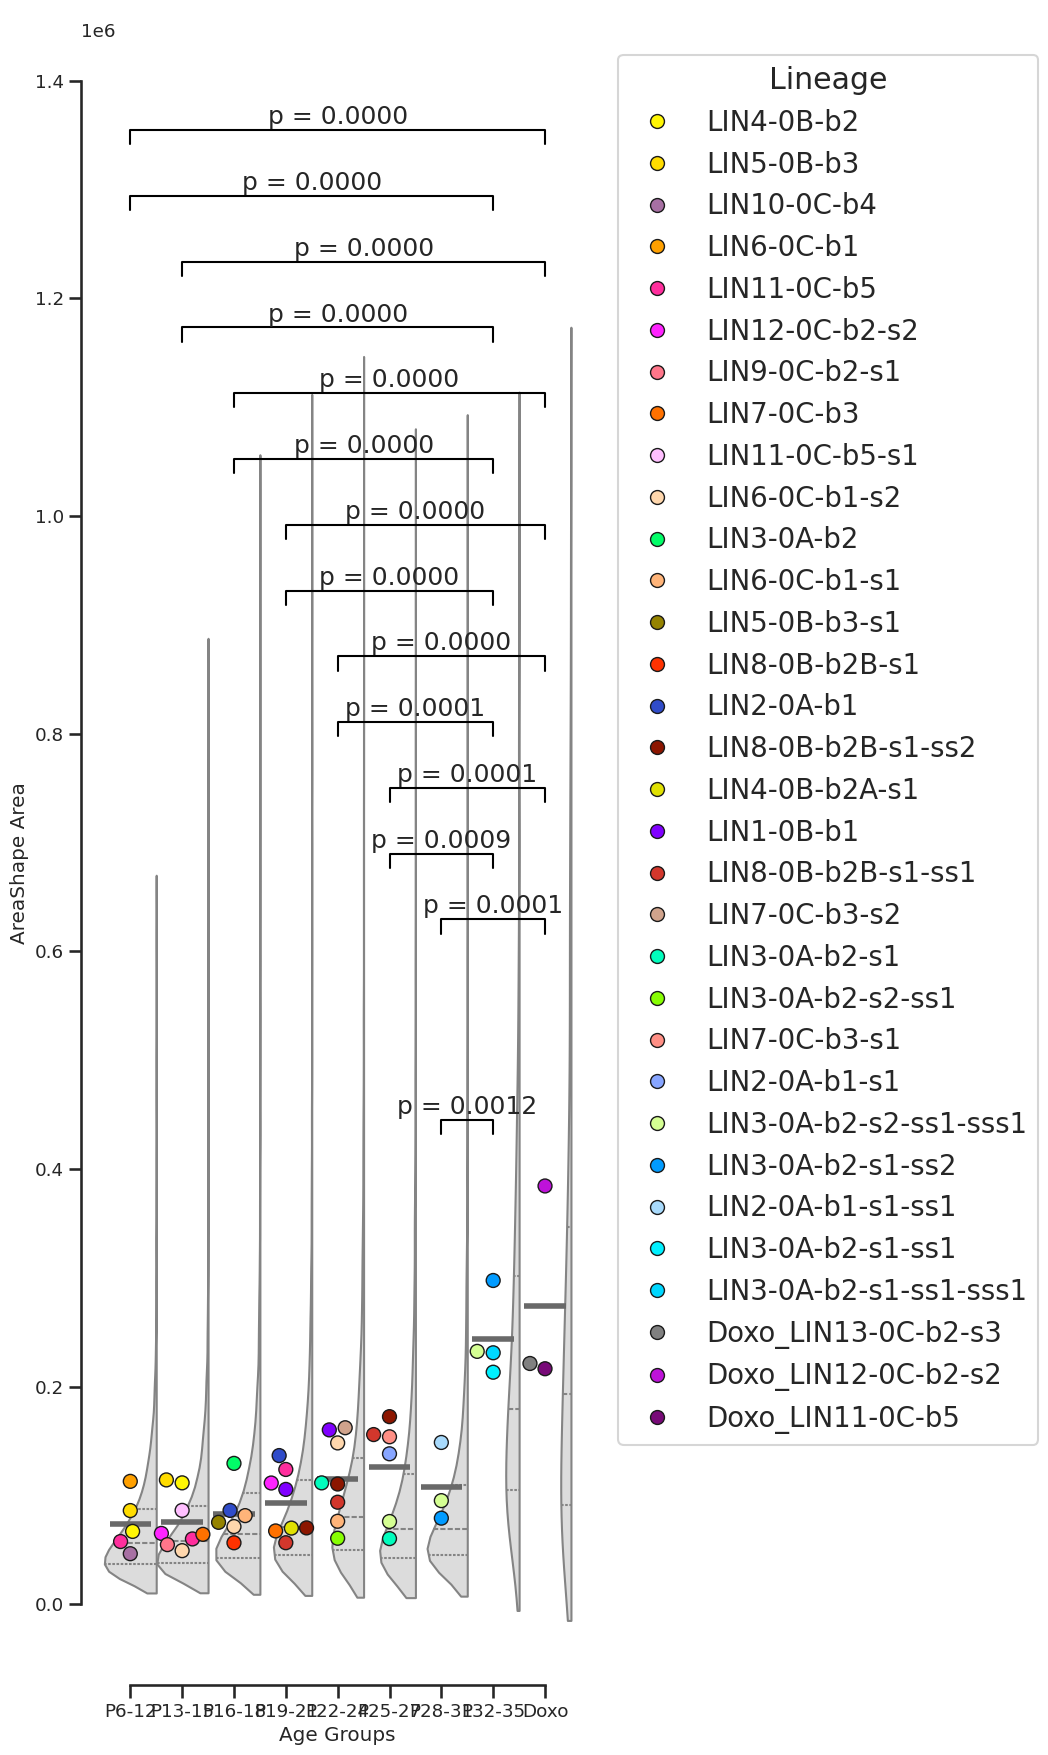

In [129]:
# Lineage Version
order = get_all_group_order()
feature_meas = "AreaShape_Area"  # Mean_Lysosomes_Distance_Centroid_Nuclei_PerCell_Area" #Mean_Lysosomes_DiameterRatio_PerCell"
ylabel = None  # "Mitochondrial Density Per Cell (relative to youngest passage)"#None#"Mitochondria per cell"
xlabel = "Age Groups"
group = "AllGroups"
stat_grouping = "Lineage"

pairs = getpairs(combined_cell_df_mitolyso, group, order)

this_df = extrafeatures_filtered_cell_df_mitolyso.copy()
data_df = this_df

# Uncomment this if the fix to add "doxo_" to the doxo lineages is not set
# no_drug_values = {None,"", "None", "none", "NoDrug", "Control", "control"}

# drug_clean = data_df["Drug"].astype(str).str.strip()
# data_df["Lineage"] = data_df["Lineage"].where(
#     data_df["Drug"].isna() | drug_clean.isin(no_drug_values),
#     drug_clean + "_" + data_df["Lineage"].astype(str),
# )

data_df["Lineage"] = data_df["Lineage"].replace(
    "LIN3-0A-b2-s2-ss1-ss1", "LIN3-0A-b2-s2-ss1-sss1"
)
#     data_df["Lineage"].equals("LIN3-0A-b2-s2-ss1-ss1"),
#     data_df["Lineage"].equals("LIN3-0A-b2-s2-ss1-sss1"),
# )


def get_hard_code_lineage_colours(
    df, lineage_col_name="Lineage", plate_col_name="Plate_Number"
):
    """
    Returns a dictionary mapping each unique lineage number to a hard-coded color.
    This ensures color consistency for each Plate_Number in seaborn/matplotlib plots.
    """
    # Get colour codes from my csv and then convert it into a dict in the {key: #hexcode} format
    colour_codes = pd.read_csv("proliferation_growth_curves/Lineage_only_hexcolour.csv")
    hard_pallete_dict = dict(
        zip(colour_codes[lineage_col_name], colour_codes["Colour"])
    )

    # print(hard_pallete_dict)
    unique_lineages = sorted(df[lineage_col_name].drop_duplicates())
    # display(unique_lineages)

    # If more lineages than colors, fill in missing colours by using a default seaborn color_palette
    for lineage in unique_lineages:
        if lineage not in hard_pallete_dict:
            extra_colours = sns.color_palette("tab20", len(unique_lineages)).as_hex()
            hard_pallete_dict = {
                lineage: extra_colours[i] for i, lineage in enumerate(unique_lineages)
            }
    return hard_pallete_dict


lindict = {
    "LIN1-0B-b1": "#8000FF",
    "LIN2-0A-b1": "#304CC9",
    "LIN3-0A-b2": "#02FD68",
    "LIN4-0B-b2": "#FFF604",
    "LIN5-0B-b3": "#FFDC00",
    "LIN6-0C-b1": "#FFA000",
    "LIN2-0A-b1-s1": "#87A5FF",
    "LIN3-0A-b2-s1": "#01FDBD",
    "LIN4-0B-b2A-s1": "#E0E102",
    "LIN5-0B-b3-s1": "#958300",
    "LIN6-0C-b1-s1": "#FFB479",
    "LIN3-0A-b2-s2-ss1": "#87FE02",
    "LIN7-0C-b3": "#FF7100",
    "LIN8-0B-b2B-s1": "#FF3200",
    "LIN9-0C-b2-s1": "#FF768A",
    "LIN10-0C-b4": "#A770A3",
    "Doxo_LIN13-0C-b2-s3": "#808080",
    "LIN3-0A-b2-s1-ss1": "#00F0FF",
    "LIN3-0A-b2-s1-ss1-sss1": "#00D7FF",
    "LIN3-0A-b2-s1-ss2": "#019BFF",
    "LIN3-0A-b2-s2-ss1-sss1": "#D5FF93",
    "LIN7-0C-b3-s1": "#FF8F85",
    "LIN8-0B-b2B-s1-ss1": "#D2372C",
    "LIN8-0B-b2B-s1-ss2": "#8C1600",
    "LIN6-0C-b1-s2": "#FFD7AD",
    "LIN11-0C-b5": "#FF2E9D",
    "Doxo_LIN11-0C-b5": "#780A78",
    "LIN12-0C-b2-s2": "#FF23FF",
    "Doxo_LIN12-0C-b2-s2": "#BE12D9",
    "LIN2-0A-b1-s1-ss1": "#A8DAFC",
    "LIN7-0C-b3-s2": "#D0A38C",
    "LIN11-0C-b5-s1": "#FFBFFF",
}
# Map each plate to a color and hard code that shit
colour_dict = get_hard_code_lineage_colours(data_df)
pallete = lindict

remove_outliers = False
reps_to_exclude = []
plot_dir = "plots/lineage"
os.makedirs(plot_dir, exist_ok=True)

figsize = (11, 18)

single_feature_super_splitviolinplot(
    data_df,
    x_value=group,
    y_value=feature_meas,
    plate_col_name=stat_grouping,
    xtitle=xlabel,
    ytitle=ylabel,
    out_dir=plot_dir,
    annotate=True,
    order=order,
    test="tukey_v3",
    reps_to_exclude=reps_to_exclude,
    show_hist=False,  # True,
    remove_outliers=False,
    truncate_outliers=True,
    legend=True,
    context="talk",
    figsize=figsize,
    pallete=pallete,
    shapiro=False,
    # p_correction="fdr_bh",
    # truncate_outliers=True
)

# NOTE: R5 has smallest cells in p23-25, which is also highest mito density


## Make multiple plots as defined

In [175]:
# take feature : label pairs to be used for plots from csv
features_df = pd.read_csv("CP_features_for_plots.csv")
display(features_df[features_df["feature"] == "AreaShape_Area"])

data_df = extrafeatures_filtered_cell_df_mitolyso.copy()
# Use in plotting loops with guaranteed alignment:


def make_feature_plots_from_csv(
    data_df,
    features_df,
    xlabel="Age Groups",
    group="AllGroups",
    analysis_mode="Plates",
    norm=False,
    order=None,
    remove_outliers=False,
    reps_to_exclude=[],
    figsize=(14, 18),
    truncate_outliers=True,
    rm_outliers_method="gesd_2",
    annotate_pval=True,
    test="tukey_v3",
    font_scale=0.8,
    annotation_location="inside",
    context="poster",
    show_legend=False,
):
    features_for_plots = features_df.to_dict("records")

    feature_df_cols = [item["feature"] for item in features_for_plots]
    feature_labels = [item["label"] for item in features_for_plots]

    if order is None:
        order = get_all_group_order()
    pairs = getpairs(data_df, group, order)

    # Set stats variables and color palette based on analysis mode
    if analysis_mode == "Lineages":
        stat_grouping = "Lineage"
        plot_dir = Path("plots/lineages")
        show_legend = True
        colour_dict = get_hard_code_lineage_colours(data_df)
    elif analysis_mode == "Plates":
        stat_grouping = "Plate_Number"
        colour_dict = get_hard_code_plate_colours(data_df)
        if norm:
            data_df = norm_combined_cell_df_mitolyso.copy()
            feature_labels = [
                f"{name} (normalized to youngest group)" for name in feature_labels
            ]
            plot_dir = Path("plots/norm")
        else:
            data_df.copy()
            plot_dir = Path("plots/notnorm")
            
    else:
        raise ValueError(
            f"Invalid analysis mode: {analysis_mode}. Use 'Lineages' or 'Plates'."
        )
    pallete = colour_dict  # "pastel"

    if annotate_pval is False:
        test = None
        plot_dir = Path(plot_dir, "simplified")
    os.makedirs(plot_dir, exist_ok=True)
    for i, feature in enumerate(feature_df_cols):
        ylabel = feature_labels[i]

        single_feature_super_splitviolinplot(
            data_df,
            x_value=group,
            y_value=feature,
            plate_col_name=stat_grouping,
            xtitle=xlabel,
            ytitle=ylabel,
            out_dir=plot_dir,
            annotate=annotate_pval,
            order=order,
            test=test,
            reps_to_exclude=reps_to_exclude,
            show_hist=False,  # True,
            remove_outliers=remove_outliers,
            rm_outliers_method=rm_outliers_method,
            truncate_outliers=truncate_outliers,
            legend=show_legend,
            context=context,
            figsize=figsize,
            pallete=pallete,
            p_correction="fdr_bh",
            shapiro=False,
            font_scale=font_scale,
            show=False,
            annotation_location=annotation_location,
        )


make_feature_plots_from_csv(
    data_df,
    features_df,
    norm=False,
    analysis_mode="Plates",
    remove_outliers=False,
    reps_to_exclude=[],
    figsize=(13, 8),
    annotate_pval=False,
    test="tukey_v3",
    font_scale=0.8,
    annotation_location="inside",
    context="poster",
)

,feature,label
0,AreaShape_Area,Cell size (px²)


TypeError: single_feature_super_splitviolinplot() got an unexpected keyword argument 'font_scale'

In [131]:
def make_a_shitton_of_plots(
    order=[],
    xlabel="Age Groups",
    group="AllGroups",
    pairs=getpairs(combined_cell_df_mitolyso, group, order),
    pallete=colour_dict,
    remove_outliers=False,
    truncate_outliers=True,
    reps_to_exclude=[],
    norm=False,
):
    if not order:
        order = get_all_group_order()

    if norm:
        this_df = norm_combined_cell_df_mitolyso.copy()
        big_out_folder = (
            "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/plots/norm"
        )
    else:
        this_df = extrafeatures_filtered_cell_df_mitolyso.copy()
        big_out_folder = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/plots/notnorm"
    os.makedirs(big_out_folder, exist_ok=True)
    # iterate and make big ball of plots
    for compartment, feature_dict in zip(feature_names, feature_dicts):
        feature_folder = Path(big_out_folder, compartment)
        Path.mkdir(feature_folder, exist_ok=True)
        for feature_type, features in feature_dict.items():
            newfolder = Path(feature_folder, feature_type)
            Path.mkdir(newfolder, exist_ok=True)
            for feature in features:
                single_feature_super_splitviolinplot(
                    this_df,
                    x_value=group,
                    y_value=feature,
                    plate_col_name="Plate_Number",
                    xtitle=xlabel,
                    ytitle=None,
                    out_dir=newfolder,
                    annotate=True,
                    order=order,
                    test="tukey_v3",
                    reps_to_exclude=reps_to_exclude,
                    show_hist=False,
                    remove_outliers=remove_outliers,
                    truncate_outliers=truncate_outliers,
                    show=False,
                    legend=True,
                    context="poster",
                    figsize=(14, 18),
                    pallete=pallete,
                    shapiro=False,
                    p_correction="fdr_bh",
                )


# make_a_shitton_of_plots(reps_to_exclude=[],norm=False)
#make_a_shitton_of_plots(reps_to_exclude=[], norm=True)

## Attempting PCA

In [132]:
vars = cell_features["areashape"]
vars = vars + nuc_features["areashape"]
vars = vars + mito_features["areashape"]
vars = vars + lyso_features["areashape"]
vars = vars + mito_features["texture"]
vars = vars + lyso_features["texture"]
vars = vars + mito_features["count"]
vars = vars + lyso_features["count"]
# vars = vars + mito_features["radialdistribution"]
vars = vars + mito_features["per_cell_area"]
vars = vars + lyso_features["per_cell_area"]
# var = vars + mito_features["granularity"]


# Stratified sampling by group
def stratified_sample(df, group_col, sample_size, random_state=40):
    """
    Take a stratified sample maintaining group proportions
    """
    # Calculate sampling fraction and sample from each group proportionally
    frac = sample_size / len(df)
    sample_df = df.groupby(group_col, group_keys=False).apply(
        lambda x: x.sample(frac=frac, random_state=random_state), include_groups=True
    )
    return sample_df


sample_df = stratified_sample(this_df, "AllGroups", sample_size=10000)

NameError: name 'cell_features' is not defined

In [ ]:
from sklearn.decomposition import PCA

n_components = 2
pca = PCA(n_components)

x_df = sample_df[vars.__add__(["AllGroups", "Plate_Number", "AreaShape_Area"])].dropna()
display(x_df)
components = pca.fit_transform(x_df[vars])
display(components)

fig = px.scatter(
    components, x=0, y=1, color=x_df["AllGroups"], symbol=x_df["Plate_Number"]
)
total_var = pca.explained_variance_ratio_.sum() * 100

# labels = {str(i): f"PC {i + 1}" for i in range(n_components)}
# labels["color"] = "AllGroups"

# fig = px.scatter_matrix(
#     components,
#     color=x_df["AllGroups"],
#     dimensions=range(n_components),
#     labels=labels,
#     title=f"Total Explained Variance: {total_var:.2f}%",
# )
# fig.update_traces(diagonal_visible=False)
fig.show()

# labels = {
#     str(i): f"PC {i + 1} ({var:.1f}%)"
#     for i, var in enumerate(pca.explained_variance_ratio_ * 100)
# }

# fig = px.scatter_matrix(
#     components, labels=labels, dimensions=range(4), color=df["species"]
# )
# fig.update_traces(diagonal_visible=False)
# fig.show()


In [ ]:
from umap import UMAP
from sklearn.preprocessing import StandardScaler

scaled_data = StandardScaler().fit_transform(x_df[vars])
reducer = UMAP(random_state=40)
reducer.fit(scaled_data)

embedding = reducer.transform(scaled_data)
# Verify that the result of calling transform is
# idenitical to accessing the embedding_ attribute
assert np.all(embedding == reducer.embedding_)
print(embedding.shape)

import sklearn.cluster as cluster

import sklearn.metrics as metrics


In [ ]:
kmeans_labels = cluster.KMeans(n_clusters=9).fit_predict(scaled_data)

"""
From https://umap-learn.readthedocs.io/en/latest/clustering.html: 
The next thing to be aware of is that when using UMAP for dimension reduction you will want to select different parameters 
than if you were using it for visualization. First of all we will want a larger n_neighbors value 
small values will focus more on very local structure and are more prone to producing fine grained cluster structure 
that may be more a result of patterns of noise in the data than actual clusters. 
In this case well double it from the default 15 up to 30. Second it is beneficial to set min_dist to a very low value. 
Since we actually want to pack points together densely (density is what we want after all) a low value will help,
as well as making cleaner separations between clusters.
In this case we will simply set min_dist to be 0.
"""
clusterable_embedding = UMAP(
    n_neighbors=30,
    min_dist=0.0,
    n_components=2,
    random_state=40,
).fit_transform(scaled_data)

# now plot the embeddings
fig = px.scatter(
    clusterable_embedding,
    x=0,
    y=1,
    color=kmeans_labels.astype(str),  # x_df["Plate_Number"],
    symbol=x_df["AllGroups"].astype(str),
    size=x_df["AreaShape_Area"],
    labels={"color": "kmeans"},
)
fig.show()


# labels = cluster.HDBSCAN(
#     min_samples=10,
#     min_cluster_size=500,
# ).fit_predict(clusterable_embedding)

fig = px.scatter(
    clusterable_embedding,
    x=0,
    y=1,
    color=x_df["Plate_Number"].astype(str),
    # symbol=x_df["Plate_Number"].astype(str),  # x_df["Plate_Number"],
    size=x_df["AreaShape_Area"],
    labels={"color": "Plate Number"},
)
fig.update_legends()
fig.show()


In [ ]:
from umap import plot
# Take a random sample of n rows

new_embedding = UMAP(
    n_components=2,
    n_neighbors=15,
    random_state=40,
).fit(scaled_data)
plot.points(new_embedding, labels=x_df.Plate_Number.astype(str), theme="fire")
plt.savefig("umap_test_2.png")

In [ ]:
# Using one-way anova and Tukey's HSD to compare means of non normalized values
order = get_all_group_order()
feature_meas = "AreaShape_Area"
ylabel = "Area"


group = "AllGroups"
plates = "Plate_Number"
pairs = getpairs(combined_cell_df_mitolyso, group, order)
this_df = extrafeatures_filtered_cell_df_mitolyso.copy()
pallete = "pastel"
remove_outliers = True

feature_df = make_single_feature_df(
    this_df, group=group, feature=feature_meas, plates="Plate_Number"
)
group_avg_df = average_groups_by_plate(
    feature_df, x_value=group, y_value=feature_meas, plates="Plate_Number"
)
group_avg_df_pivot = average_groups_pivot(
    group_avg_df, x_value=group, y_value=feature_meas, plate_col_name="Plate_Number"
)

if remove_outliers is True:
    feature_df = remove_outliers_iqr(feature_df)
    display(feature_df)

display(feature_df)
display(group_avg_df)
display(group_avg_df_pivot)

sns.set_theme(style="ticks")
# sns.set_context("notebook", font_scale=1.9)

plt.figure(figsize=(12, 8))
sns.set_context("talk", font_scale=0.5)
plt.figure(dpi=300)


sns.violinplot(
    data=feature_df,
    x=group,
    y=feature_meas,
    order=order,
    fill=False,
    color="gainsboro",
    cut=1,
    native_scale=True,
    linecolor="k",
    inner=None,
    # inner_kws=dict(box_width = 5)
)

ax = sns.swarmplot(
    data=group_avg_df,
    x=group,
    y=feature_meas,
    hue=plates,
    order=order,
    palette=pallete,
    size=10,
    edgecolor="k",
    linewidth=1,
    dodge=0.5,
)

# use a boxplot to draw the mean line - thinking outside the box :)
sns.boxplot(
    data=group_avg_df,
    x=group,
    y=feature_meas,
    showmeans=True,
    meanline=True,
    meanprops={"color": "dimgray", "ls": "-", "lw": 2.5},
    medianprops={"visible": False},
    whiskerprops={"visible": False},
    zorder=1,
    showfliers=False,
    showbox=False,
    showcaps=False,
    ax=ax,
)

ax.legend_.remove()

sns.despine()
plt.gcf()  # .set_size_inches(10, 6)
plt.xlabel(group)
if ylabel == None:
    plt.ylabel(feature_meas.replace("_", " "))


from statannotations.Annotator import Annotator
from statannotations.stats.StatTest import StatTest

# Extract the data for each group

# Perform the one-way ANOVA test

# Print the results

pvalues, pairs = anova_with_tukey_posthoc(
    group_avg_df, x_value=group, y_value=feature_meas, display_results=True
)


annotator = Annotator(ax, pairs, data=group_avg_df_pivot, order=order)
annotator.configure(
    text_format="star", loc="inside", verbose=2, hide_non_significant=True
)
annotator.set_pvalues_and_annotate(pvalues)

plt.savefig("plots/new_plots/" + feature_meas + "_anova_superviolinplot.png", dpi=300)
plt.show()


## Summary Stats

In [ ]:
summary_outpath = "postprocessed_summary_stats"
os.makedirs(summary_outpath, exist_ok=True)

feature_cols = [
    "AreaShape_Area",
    "Nuclei_AreaShape_Area",
    "Cell_Nuclei_Area_Ratio",
    "Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized",
    "Intensity_MeanIntensity_LAMP1_MAX_WellNormalized",
    "Intensity_MeanIntensity_MitoTracker_MAX_WellNormalized",
    "Neighbors_NumberOfNeighbors_5",
    "Neighbors_PercentTouching_5",
    "Nuclei_Neighbors_NumberOfNeighbors_1",
    "Nuclei_Neighbors_PercentTouching_1",
    "Children_Lysosomes_Count",
    "Children_Mitochondria_Count",
]
include_cols = ["Number_Object_Number"] + feature_cols
print(include_cols)


def make_summary_stats_for_df_and_feature(
    df,
    x_value,
    feature,
    summary_outpath,
    df_tag="original",
    plate_col_name="Plate_Number",
    feature_name="area",
    group_name="passage_group",
    include_cols=[],
    inculded_percentiles=[
        0.01,
        0.025,
        0.05,
        0.1,
        0.25,
        0.5,
        0.75,
        0.9,
        0.95,
        0.975,
        0.99,
    ],
):
    from pathlib import Path

    try:
        table_csvname = f"{df_tag}_total_combined_stats.csv"
        feature_csvname = f"{df_tag}_{feature_name}_by_{group_name}_stats.csv"
        agg_feature_csvname = f"{df_tag}_agg_{feature_name}_by_{group_name}_stats.csv"

        subfolder_name = f"{df_tag}_{feature_name}_summary_stats"
        parent_folder = Path(summary_outpath, subfolder_name)
        parent_folder.mkdir(exist_ok=True)

        if not include_cols:
            df_to_summarize = df
        else:
            df_to_summarize = df[include_cols]
        df_to_summarize.describe(percentiles=inculded_percentiles).to_csv(
            os.path.join(summary_outpath, table_csvname)
        )
        group_averages = df.groupby(
            [x_value, plate_col_name], as_index=False, observed=True
        )[feature]
        # Reset the index to get a clean DataFrame
        # average_df = group_averages.reset_index()
        avg_summary = group_averages.describe(percentiles=inculded_percentiles)
        avg_summary_sorted = avg_summary.sort_values(
            by=[x_value], key=lambda x: x.map(passage_groups_sort_key)
        ).reset_index(drop=True)
        avg_summary_sorted.to_csv(
            os.path.join(summary_outpath, subfolder_name, feature_csvname)
        )

        # do the agg by passage group only
        group_averages_agg = df.groupby([x_value], as_index=False, observed=True)[
            feature
        ]
        avg_agg_summary = group_averages_agg.describe(percentiles=inculded_percentiles)
        avg_agg_summary_sorted = avg_agg_summary.sort_values(
            by=[x_value], key=lambda x: x.map(passage_groups_sort_key)
        ).reset_index(drop=True)
        avg_agg_summary_sorted.T.to_csv(
            os.path.join(summary_outpath, subfolder_name, agg_feature_csvname)
        )
        print(
            f"saved files {(table_csvname, feature_csvname, agg_feature_csvname)} to {summary_outpath}"
        )
        return True
    except ValueError as e:
        print(f"Could not make summary stats: {e}")
        return False


this_df = combined_cell_df_mitolyso #extrafeatures_filtered_cell_df_mitolyso.copy()


for feature in feature_cols:
    df_sorted = this_df.sort_values(
        by=["AllGroups"], key=lambda x: x.map(passage_groups_sort_key)
    ).reset_index(drop=True)
    make_summary_stats_for_df_and_feature(
        df_sorted,
        "AllGroups",
        feature,
        summary_outpath,
        df_tag="original",
        feature_name=feature,
        include_cols=include_cols,
    )
    # seaborn_ridgeplot(
    #     df_sorted,
    #     value_col=feature,
    #     group_col="AllGroups",
    #     palette="Set2",
    #     save=True,
    #     out_dir=summary_outpath,
    #     show_percentiles=True,
    #     truncate_outliers=True,
    # )


### To export the normalized csv:


In [ ]:
combined_cell_df_mitolyso_borders_excluded = pd.read_csv(
    os.path.join(csvpath, filename_borders_excluded)
)
filtered_borders_excluded = apply_all_filters(
    combined_cell_df_mitolyso_borders_excluded
)

for feature in feature_cols:
    make_summary_stats_for_df_and_feature(
        filtered_borders_excluded,
        "AllGroups",
        feature,
        summary_outpath,
        df_tag="borders_excluded",
        feature_name=feature,
        include_cols=include_cols,
    )


In [ ]:
preprocessed_df = extrafeatures_filtered_cell_df_mitolyso.copy()

preprocessed_df.to_csv(
    os.path.join(csvpath, "CellProfiler_features_preprocessed.csv"), index=False
)

norm_cell_df_mitolyso.to_csv(
    os.path.join(csvpath, "Norm_CellProfiler_features_preprocessed.csv"),
    index=False,
)